# Fair-BorderlineSMOTE: Gender-Aware Oversampling for Bias Mitigation in Recidivism Prediction

| | |
|---|---|
| **Dataset** | COMPAS Recidivism (ProPublica) |
| **Target** | `two_year_recid` — whether a defendant reoffended within two years |
| **Protected attribute** | `sex` (gender: Male / Female) |
| **Oversampling methods** | Baseline · SMOTE · BorderlineSMOTE · ADASYN · Fair-BorderlineSMOTE |
| **Classifiers** | Logistic Regression · Random Forest · XGBoost |

**Fair-BorderlineSMOTE** stratifies oversampling by gender × class subgroup, detects
borderline (danger-zone) samples using a kNN fitted on the full training set,
and synthesizes new samples exclusively from within each gender subgroup —
ensuring no cross-gender interpolation occurs.


In [ ]:
!pip install imbalanced-learn xgboost --quiet

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score,
                              precision_score, recall_score)
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

np.random.seed(42)
print('All imports successful.')


All imports successful.


---
## 1. Load COMPAS Dataset


In [ ]:
from google.colab import files
print('Upload compas-scores-two-years.csv')
print('Main Source: https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm')
print('Download Data Source: https://github.com/joymallyac/Fair-SMOTE/blob/master/data/compas-scores-two-years.csv')
uploaded = files.upload()


Upload compas-scores-two-years.csv
Main Source: https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm
Download Data Source: https://github.com/joymallyac/Fair-SMOTE/blob/master/data/compas-scores-two-years.csv


Saving compas_fair_bls_results.csv to compas_fair_bls_results.csv


In [ ]:
df_raw = pd.read_csv('compas-scores-two-years.csv')
# Show all columns
pd.set_option('display.max_columns', None)
df_raw.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,8/14/2013,Male,4/18/1947,69,Greater than 45,Other,0,1,0,0,0,-1.0,8/13/2013 6:03,8/14/2013 5:41,13011352CF10A,8/13/2013,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,Low,8/14/2013,Risk of Violence,1,Low,8/14/2013,7/7/2014,7/14/2014,0,327,0,0
1,3,kevon dixon,kevon,dixon,1/27/2013,Male,1/22/1982,34,25 - 45,African-American,0,3,0,0,0,-1.0,1/26/2013 3:45,2/5/2013 5:36,13001275CF10A,1/26/2013,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,7/5/2013,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),7/5/2013,Felony Battery (Dom Strang),Risk of Recidivism,Low,1/27/2013,Risk of Violence,1,Low,1/27/2013,1/26/2013,2/5/2013,9,159,1,1
2,4,ed philo,ed,philo,4/14/2013,Male,5/14/1991,24,Less than 25,African-American,0,4,0,1,4,-1.0,4/13/2013 4:58,4/14/2013 7:02,13005330CF10A,4/13/2013,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,6/16/2013,Driving Under The Influence,6/16/2013,6/16/2013,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,Low,4/14/2013,Risk of Violence,3,Low,4/14/2013,6/16/2013,6/16/2013,0,63,0,1
3,5,marcu brown,marcu,brown,1/13/2013,Male,1/21/1993,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,1/12/2013,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,High,1/13/2013,Risk of Violence,6,Medium,1/13/2013,NaN,NaN,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,3/26/2013,Male,1/22/1973,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,1/9/2013,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,Low,3/26/2013,Risk of Violence,1,Low,3/26/2013,NaN,NaN,0,1102,0,0


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 51 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7214 non-null   int64  
 1   name                     7214 non-null   object 
 2   first                    7214 non-null   object 
 3   last                     7214 non-null   object 
 4   compas_screening_date    7214 non-null   object 
 5   sex                      7214 non-null   object 
 6   dob                      7214 non-null   object 
 7   age                      7214 non-null   int64  
 8   age_cat                  7214 non-null   object 
 9   race                     7214 non-null   object 
 10  juv_fel_count            7214 non-null   int64  
 11  decile_score             7214 non-null   int64  
 12  juv_misd_count           7214 non-null   int64  
 13  juv_other_count          7214 non-null   int64  
 14  priors_count            

In [ ]:
# Check missing value
df_raw.isnull().sum()

,0
id,0
name,0
first,0
last,0
compas_screening_date,0
sex,0
dob,0
age,0
age_cat,0
race,0


In [ ]:
# Standard ProPublica filtering
df = df_raw[
    (df_raw['days_b_screening_arrest'] <= 30) &
    (df_raw['days_b_screening_arrest'] >= -30) &
    (df_raw['is_recid'] != -1) &
    (df_raw['c_charge_degree'] != 'O') &
    (df_raw['score_text'] != 'N/A')
].copy()
df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,8/14/2013,Male,4/18/1947,69,Greater than 45,Other,0,1,0,0,0,-1.0,8/13/2013 6:03,8/14/2013 5:41,13011352CF10A,8/13/2013,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,Low,8/14/2013,Risk of Violence,1,Low,8/14/2013,7/7/2014,7/14/2014,0,327,0,0
1,3,kevon dixon,kevon,dixon,1/27/2013,Male,1/22/1982,34,25 - 45,African-American,0,3,0,0,0,-1.0,1/26/2013 3:45,2/5/2013 5:36,13001275CF10A,1/26/2013,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,7/5/2013,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),7/5/2013,Felony Battery (Dom Strang),Risk of Recidivism,Low,1/27/2013,Risk of Violence,1,Low,1/27/2013,1/26/2013,2/5/2013,9,159,1,1
2,4,ed philo,ed,philo,4/14/2013,Male,5/14/1991,24,Less than 25,African-American,0,4,0,1,4,-1.0,4/13/2013 4:58,4/14/2013 7:02,13005330CF10A,4/13/2013,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,6/16/2013,Driving Under The Influence,6/16/2013,6/16/2013,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,Low,4/14/2013,Risk of Violence,3,Low,4/14/2013,6/16/2013,6/16/2013,0,63,0,1
5,7,marsha miles,marsha,miles,11/30/2013,Male,8/22/1971,44,25 - 45,Other,0,1,0,0,0,0.0,11/30/2013 4:50,12/1/2013 12:28,13022355MM10A,11/30/2013,NaN,0.0,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,Low,11/30/2013,Risk of Violence,1,Low,11/30/2013,11/30/2013,12/1/2013,1,853,0,0
6,8,edward riddle,edward,riddle,2/19/2014,Male,7/23/1974,41,25 - 45,Caucasian,0,6,0,0,14,-1.0,2/18/2014 5:08,2/24/2014 12:18,14002304CF10A,2/18/2014,NaN,1.0,F,Possession Burglary Tools,1,14004485CF10A,(F2),0.0,3/31/2014,Poss of Firearm by Convic Felo,3/31/2014,4/18/2014,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,Medium,2/19/2014,Risk of Violence,2,Low,2/19/2014,3/31/2014,4/18/2014,5,40,1,1


In [ ]:
keep_cols = ['age', 'sex', 'race', 'juv_fel_count', 'juv_misd_count',
             'juv_other_count', 'priors_count', 'c_charge_degree',
             'two_year_recid']
df = df[keep_cols].dropna()
df['sex']  = df['sex'].str.strip()
df['race'] = df['race'].str.strip()
df = df[df['sex'].isin(['Male', 'Female'])].reset_index(drop=True)
df.head()

,age,sex,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,two_year_recid
0,69,Male,Other,0,0,0,0,F,0
1,34,Male,African-American,0,0,0,0,F,1
2,24,Male,African-American,0,0,1,4,F,1
3,44,Male,Other,0,0,0,0,M,0
4,41,Male,Caucasian,0,0,0,14,F,1


In [ ]:
print(f'COMPAS — shape: {df.shape}')
print(f'\nTarget (two_year_recid):')
print(df['two_year_recid'].value_counts())
print(f'\nGender (sex):')
print(df['sex'].value_counts())
print(f'\nGender x Class breakdown:')
print(df.groupby(['sex', 'two_year_recid']).size().unstack(fill_value=0))
print(f'\nOverall positive rate : {df["two_year_recid"].mean()*100:.1f}%')
print(f'Positive rate — Male  : {df[df["sex"]=="Male"]["two_year_recid"].mean()*100:.1f}%')
print(f'Positive rate — Female: {df[df["sex"]=="Female"]["two_year_recid"].mean()*100:.1f}%')

COMPAS — shape: (6172, 9)

Target (two_year_recid):
two_year_recid
0    3363
1    2809
Name: count, dtype: int64

Gender (sex):
sex
Male      4997
Female    1175
Name: count, dtype: int64

Gender x Class breakdown:
two_year_recid     0     1
sex                       
Female           762   413
Male            2601  2396

Overall positive rate : 45.5%
Positive rate — Male  : 47.9%
Positive rate — Female: 35.1%


## Target & gender distribution

  COMPAS Dataset — Descriptive Statistics

── Target: two_year_recid ──


,Label,Count,Percent
0,No recidivism,3363,54.49%
1,Recidivism,2809,45.51%



── Gender: sex ──


,Count,Percent
sex,,
Male,4997,80.96%
Female,1175,19.04%



── Gender breakdown within each class of two_year_recid ──


,Female Count,Female %,Male Count,Male %,Total
two_year_recid,,,,,
No recidivism (0),762,22.66%,2601,77.34%,3363
Recidivism (1),413,14.70%,2396,85.30%,2809
Total,1175,0.00%,4997,0.00%,6172



── Target class breakdown within each gender ──


,No Recid (0) Count,No Recid (0) %,Recid (1) Count,Recid (1) %,Total
sex,,,,,
Female,762,64.85%,413,35.15%,1175
Male,2601,52.05%,2396,47.95%,4997
Total,3363,0.00%,2809,0.00%,6172


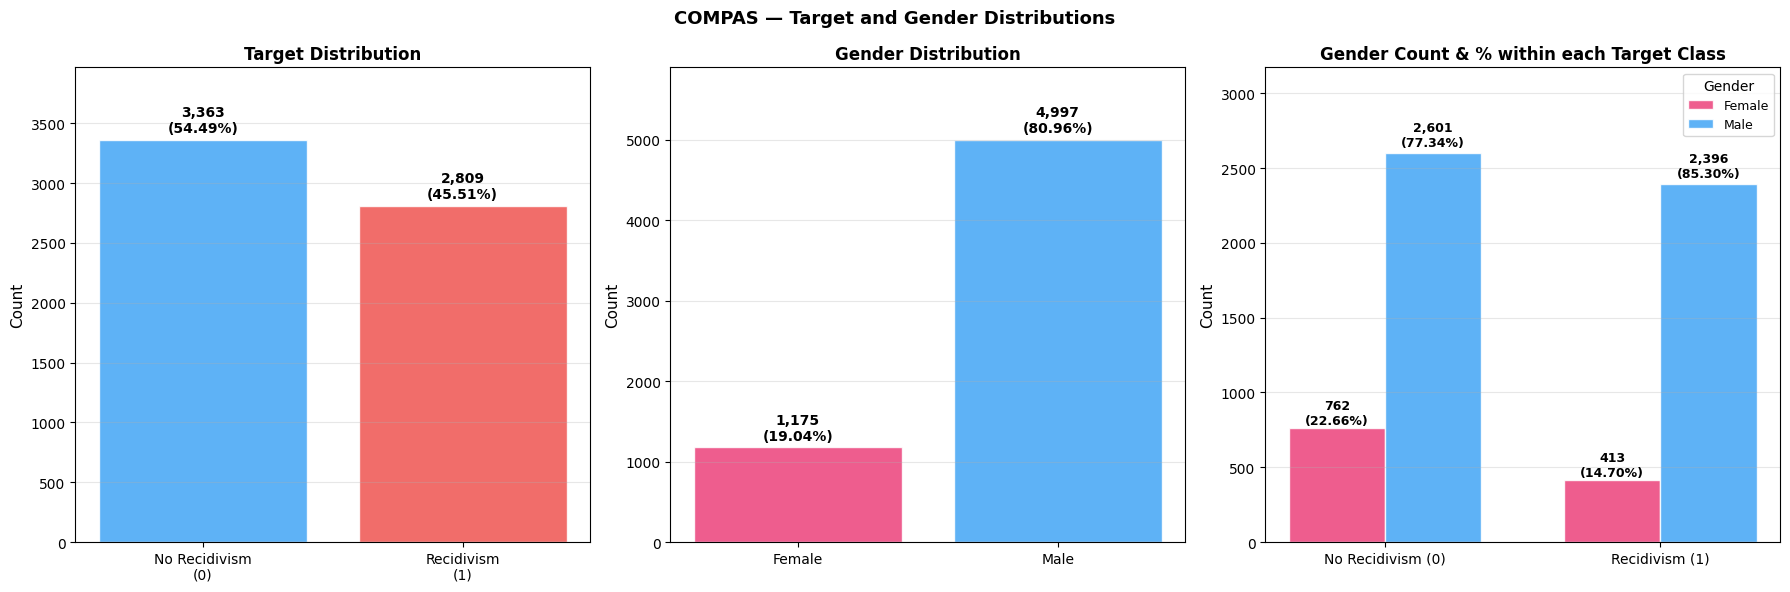

Saved plot_distributions.png


In [ ]:
# ==================================================================================
# Target distribution, gender distribution, and
# gender breakdown within each class of the target
# ==================================================================================

print('=' * 55)
print('  COMPAS Dataset — Descriptive Statistics')
print('=' * 55)

# ── 1. Target distribution ──
print('\n── Target: two_year_recid ──')
target_counts = df['two_year_recid'].value_counts().sort_index()
target_pct    = df['two_year_recid'].value_counts(normalize=True).sort_index() * 100
target_summary = pd.DataFrame({
    'Label':   {0: 'No recidivism', 1: 'Recidivism'},
    'Count':   target_counts,
    'Percent': target_pct.round(2),
})
target_summary['Percent'] = target_summary['Percent'].map('{:.2f}%'.format)
display(target_summary)

# ── 2. Gender distribution ──
print('\n── Gender: sex ──')
sex_counts = df['sex'].value_counts()
sex_pct    = df['sex'].value_counts(normalize=True) * 100
sex_summary = pd.DataFrame({
    'Count':   sex_counts,
    'Percent': sex_pct.round(2),
})
sex_summary['Percent'] = sex_summary['Percent'].map('{:.2f}%'.format)
display(sex_summary)

# ── 3. Gender percentage within each target class ──
print('\n── Gender breakdown within each class of two_year_recid ──')
cross = pd.crosstab(
    df['two_year_recid'], df['sex'],
    margins=True, margins_name='Total')
cross_pct = pd.crosstab(
    df['two_year_recid'], df['sex'],
    normalize='index') * 100

combined = pd.DataFrame(index=cross.index)
for gender in ['Female', 'Male']:
    if gender in cross.columns:
        combined[f'{gender} Count'] = cross[gender]
        combined[f'{gender} %']     = cross_pct[gender].reindex(
            cross.index).fillna(0).round(2).map('{:.2f}%'.format)
combined['Total'] = cross['Total']
combined.index    = combined.index.map(
    lambda x: {0: 'No recidivism (0)',
               1: 'Recidivism (1)',
               'Total': 'Total'}.get(x, x))
display(combined)

# ── 4. Target class percentage within each gender ──
print('\n── Target class breakdown within each gender ──')
cross_by_sex = pd.crosstab(
    df['sex'], df['two_year_recid'],
    margins=True, margins_name='Total')
cross_by_sex_pct = pd.crosstab(
    df['sex'], df['two_year_recid'],
    normalize='index') * 100

combined2 = pd.DataFrame(index=cross_by_sex.index)
for cls, label in [(0, 'No Recid (0)'), (1, 'Recid (1)')]:
    if cls in cross_by_sex.columns:
        combined2[f'{label} Count'] = cross_by_sex[cls]
        combined2[f'{label} %']     = cross_by_sex_pct[cls].reindex(
            cross_by_sex.index).fillna(0).round(2).map('{:.2f}%'.format)
combined2['Total'] = cross_by_sex['Total']
display(combined2)

# ── 5. Visual summary ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('COMPAS — Target and Gender Distributions',
             fontsize=13, fontweight='bold')


def label_bars(ax, bars, counts, pcts, fontsize=10):
    """Place count and percentage above each bar."""
    y_pad = ax.get_ylim()[1] * 0.01
    for bar, cnt, pct in zip(bars, counts, pcts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_pad,
            f'{int(cnt):,}\n({pct:.2f}%)',
            ha='center', va='bottom',
            fontsize=fontsize, fontweight='bold')


# ── Panel 1: Target distribution ──
target_bars = axes[0].bar(
    ['No Recidivism\n(0)', 'Recidivism\n(1)'],
    target_counts.values,
    color=['#42A5F5', '#EF5350'], alpha=0.85, edgecolor='white')
axes[0].set_title('Target Distribution', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, target_counts.max() * 1.18)
label_bars(axes[0], target_bars,
           target_counts.values, target_pct.values)

# ── Panel 2: Gender distribution ──
sex_order  = ['Female', 'Male']
sex_vals   = sex_counts.reindex(sex_order)
sex_pct_v  = sex_pct.reindex(sex_order)
sex_bars   = axes[1].bar(
    sex_order, sex_vals.values,
    color=['#EC407A', '#42A5F5'], alpha=0.85, edgecolor='white')
axes[1].set_title('Gender Distribution', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, sex_vals.max() * 1.18)
label_bars(axes[1], sex_bars,
           sex_vals.values, sex_pct_v.values)

# ── Panel 3: Grouped bar — gender count within each target class ──
cross_counts = pd.crosstab(df['two_year_recid'], df['sex'])
cross_pcts   = pd.crosstab(df['two_year_recid'], df['sex'],
                            normalize='index') * 100

class_labels = ['No Recidivism (0)', 'Recidivism (1)']
x   = np.arange(len(class_labels))
w   = 0.35
g_colors = ['#EC407A', '#42A5F5']

for i, gender in enumerate(['Female', 'Male']):
    counts = cross_counts[gender].values
    pcts   = cross_pcts[gender].values
    bars   = axes[2].bar(
        x + i * w, counts, width=w,
        label=gender, color=g_colors[i],
        alpha=0.85, edgecolor='white')
    # Numeric label: count + % on top of each bar
    y_pad = axes[2].get_ylim()[1] * 0.01
    for bar, cnt, pct in zip(bars, counts, pcts):
        axes[2].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_pad,
            f'{int(cnt):,}\n({pct:.2f}%)',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

axes[2].set_title('Gender Count & % within each Target Class',
                  fontweight='bold', fontsize=12)
axes[2].set_ylabel('Count', fontsize=11)
axes[2].set_xticks(x + w / 2)
axes[2].set_xticklabels(class_labels, fontsize=10)
axes[2].set_ylim(0, cross_counts.values.max() * 1.22)
axes[2].legend(title='Gender', fontsize=9)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot_distributions.png')

---
## 2. Preprocessing


In [ ]:
LABEL_COL = 'two_year_recid'
SEX_COL   = 'sex'

# Preserve raw gender strings for fairness evaluation
sex_raw = df[SEX_COL].values.copy()

# Label-encode all categorical columns
df_enc = df.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

FEAT_COLS = [c for c in df_enc.columns if c != LABEL_COL]

X_all   = df_enc[FEAT_COLS].values.astype(float)
y_all   = df_enc[LABEL_COL].values.astype(int)
sex_all = sex_raw[:len(X_all)]

# Stratified 80/20 split
X_tr, X_te, y_tr, y_te, sex_tr, sex_te = train_test_split(
    X_all, y_all, sex_all,
    test_size=0.2, random_state=42, stratify=y_all)

# StandardScaler fitted on train only, applied to test
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

print(f'Train: {len(X_tr_sc):,}  |  Test: {len(X_te_sc):,}')
print(f'Train class dist : {dict(pd.Series(y_tr).value_counts())}')
print(f'Train gender dist: {dict(pd.Series(sex_tr).value_counts())}')
print(f'Test  gender dist: {dict(pd.Series(sex_te).value_counts())}')
print(f'Feature columns ({len(FEAT_COLS)}): {FEAT_COLS}')


Train: 4,937  |  Test: 1,235
Train class dist : {0: np.int64(2690), 1: np.int64(2247)}
Train gender dist: {'Male': np.int64(3995), 'Female': np.int64(942)}
Test  gender dist: {'Male': np.int64(1002), 'Female': np.int64(233)}
Feature columns (8): ['age', 'sex', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'c_charge_degree']


---
## 3. Fair-BorderlineSMOTE Implementation


Fair-BorderlineSMOTE iterates over every **(gender, class)** subgroup and:
1. Detects **borderline (danger-zone)** samples using a kNN fitted on the **full training set**: a sample is borderline if `0 < majority_neighbors < m`
2. Synthesizes new samples from borderline seeds only, using a kNN fitted **within the gender subgroup** — no cross-gender interpolation
3. Continues until each subgroup reaches `max_size` (the size of the largest subgroup)


In [ ]:
# ==============================================================================
# Vectorized synthesis core
# ==============================================================================
def _synthesize(sub_arr, seed_idx, knn_within, to_gen, cr=0.8):
    """
    Generate `to_gen` synthetic samples from `seed_idx` pool.
    Uses NumPy broadcasting — no Python loop over individual samples.

    Parameters
    ----------
    sub_arr    : ndarray (n_sub, n_feat)  subgroup feature matrix
    seed_idx   : 1-D array of borderline seed indices into sub_arr
    knn_within : NearestNeighbors fitted on sub_arr (within-group),
                 must have n_neighbors >= min(4, len(sub_arr))
    to_gen     : number of synthetic samples to produce
    cr         : crossover rate — probability of using interpolated value [0,1]

    Returns
    -------
    ndarray (to_gen, n_feat)
    """
    if len(seed_idx) == 0 or to_gen == 0:
        return np.empty((0, sub_arr.shape[1]))

    # Guard: subgroup too small for proper kNN — tile existing samples
    if len(sub_arr) < 3:
        return np.tile(sub_arr, (to_gen // len(sub_arr) + 1, 1))[:to_gen]

    seed    = sub_arr[seed_idx]
    pi      = np.random.randint(0, len(seed), to_gen)   # random parent indices
    parents = seed[pi]

    k_q     = min(4, len(sub_arr))          # +1 slot to absorb self-neighbor
    _, nbrs = knn_within.kneighbors(parents, n_neighbors=k_q)
    nbrs    = nbrs[:, 1:]                   # drop self (distance = 0)
    c1      = sub_arr[nbrs[:, 0]]
    c2      = sub_arr[nbrs[:, min(1, nbrs.shape[1] - 1)]]

    f_vec   = np.random.uniform(0, 1, (to_gen, 1))      # per-sample scale
    cr_mask = np.random.rand(to_gen, sub_arr.shape[1]) < cr
    result  = np.where(cr_mask, parents + f_vec * (c1 - c2), parents)

    return np.clip(result, sub_arr.min(axis=0), sub_arr.max(axis=0))


# ==============================================================================
# Fair-BorderlineSMOTE
# ==============================================================================
def fair_borderline_smote(X_tr, y_tr, sex_tr, k=5, m=10, cr=0.8):
    """
    Fair-BorderlineSMOTE stratified by gender.

    For each (gender, class) subgroup:
      1. Detect borderline samples: knn_full (full dataset) is used so that
         majority-class neighbors from OTHER gender groups are also counted,
         giving a fair picture of how borderline each sample is globally.
      2. Synthesize from borderline seeds using knn_within (within gender),
         so synthetic samples stay inside the subgroup's feature distribution.
         Interpolation scale is drawn per sample from Uniform(0, 1) rather
         than fixed, matching standard SMOTE behaviour.

    Parameters
    ----------
    X_tr, y_tr  : training features and labels
    sex_tr      : gender array aligned with X_tr (string: 'Male'/'Female')
    k           : within-group kNN neighbors for synthesis
    m           : full-dataset kNN neighbors for borderline detection
    cr          : crossover rate passed to _synthesize [0, 1]

    Returns
    -------
    X_aug, y_aug, sex_aug, log_df
    """
    X = np.array(X_tr, dtype=float)
    y = np.array(y_tr)
    s = np.array(sex_tr)

    m_act    = min(m, len(X) - 1)
    knn_full = NearestNeighbors(
        n_neighbors=m_act, algorithm='kd_tree', n_jobs=-1).fit(X)
    max_size = int(pd.Series(y).value_counts().max())

    Xs, ys, ss = [X], [y], [s]
    log = []

    for cl in sorted(np.unique(y)):
        for sv in sorted(np.unique(s)):
            mask   = (y == cl) & (s == sv)
            sub    = X[mask]
            to_gen = max(0, max_size - mask.sum())

            # Aligned with _synthesize's own < 3 guard
            if len(sub) < 3 or to_gen == 0:
                log.append({'gender': sv, 'class': cl,
                            'subgroup_size': len(sub),
                            'borderline': 0, 'generated': 0})
                continue

            # Step 1: borderline detection (full-dataset kNN)
            _, idx = knn_full.kneighbors(sub, n_neighbors=m_act)
            maj    = np.sum(y[idx] != cl, axis=1)
            bl     = np.where((maj > 0) & (maj < m_act))[0]

            if not len(bl):
                log.append({'gender': sv, 'class': cl,
                            'subgroup_size': len(sub),
                            'borderline': 0, 'generated': 0})
                continue

            # Step 2: synthesis (within-gender kNN)
            # k + 2: one slot for self-neighbor, k true neighbors
            knn_in = NearestNeighbors(
                n_neighbors=min(k + 2, len(sub)),
                algorithm='kd_tree', n_jobs=-1).fit(sub)
            synth  = _synthesize(sub, bl, knn_in, to_gen, cr)   # f removed

            if len(synth):
                Xs.append(synth)
                ys.append(np.full(len(synth), cl))
                ss.append(np.full(len(synth), sv))

            log.append({'gender': sv, 'class': cl,
                        'subgroup_size': len(sub),
                        'borderline': len(bl),
                        'generated': len(synth)})

    log_df = pd.DataFrame(log)
    return np.vstack(Xs), np.concatenate(ys), np.concatenate(ss), log_df


print('Fair-BorderlineSMOTE ready.')

Fair-BorderlineSMOTE ready.


In [ ]:
# Quick test on training data
print('Testing Fair-BorderlineSMOTE...')
X_test_aug, y_test_aug, s_test_aug, test_log = fair_borderline_smote(
    X_tr_sc, y_tr, sex_tr, k=5, m=10)
print(f'  Original train size : {len(X_tr_sc):,}')
print(f'  Augmented train size: {len(X_test_aug):,}  '
      f'(+{len(X_test_aug)-len(X_tr_sc):,} synthetic)')
print(f'\nSubgroup synthesis log:')
display(test_log)

Testing Fair-BorderlineSMOTE...
  Original train size : 4,937
  Augmented train size: 10,760  (+5,823 synthetic)

Subgroup synthesis log:


,gender,class,subgroup_size,borderline,generated
0,Female,0,614,535,2076
1,Male,0,2076,1988,614
2,Female,1,328,320,2362
3,Male,1,1919,1837,771


---
## 4. Fairness Metrics


In [ ]:
def demographic_parity_diff(y_pred, sex):
    """Max difference in positive prediction rates across gender groups."""
    groups = np.unique(sex)
    rates  = {g: y_pred[sex == g].mean() for g in groups}
    vals   = list(rates.values())
    return round(max(vals) - min(vals), 4), rates


def equalized_odds_diff(y_true, y_pred, sex):
    """Max TPR and FPR difference across gender groups."""
    groups = np.unique(sex)
    tpr, fpr = {}, {}
    for g in groups:
        m  = sex == g
        yt, yp = y_true[m], y_pred[m]
        tp = ((yt==1)&(yp==1)).sum(); fn = ((yt==1)&(yp==0)).sum()
        fp = ((yt==0)&(yp==1)).sum(); tn = ((yt==0)&(yp==0)).sum()
        tpr[g] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr[g] = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tv = list(tpr.values()); fv = list(fpr.values())
    return (round(max(tv) - min(tv), 4),
            round(max(fv) - min(fv), 4),
            tpr, fpr)


def compute_metrics(y_true, y_pred, y_prob, sex):
    """Combine performance and gender fairness metrics."""
    dp, rates           = demographic_parity_diff(y_pred, sex)
    tpr_d, fpr_d, tpr_g, fpr_g = equalized_odds_diff(y_true, y_pred, sex)
    return {
        'accuracy':    round(accuracy_score(y_true, y_pred), 4),
        'f1':          round(f1_score(y_true, y_pred, zero_division=0), 4),
        'auc':         round(roc_auc_score(y_true, y_prob), 4),
        'precision':   round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall':      round(recall_score(y_true, y_pred, zero_division=0), 4),
        'dp_diff':     dp,
        'tpr_diff':    tpr_d,
        'fpr_diff':    fpr_d,
        'rate_female': rates.get('Female', np.nan),
        'rate_male':   rates.get('Male',   np.nan),
        'tpr_female':  tpr_g.get('Female', np.nan),
        'tpr_male':    tpr_g.get('Male',   np.nan),
        'fpr_female':  fpr_g.get('Female', np.nan),
        'fpr_male':    fpr_g.get('Male',   np.nan),
    }

print('Fairness metrics ready.')


Fairness metrics ready.


---
## 5. Experiment Setup


In [ ]:
def get_classifiers():
    return {

        # ── Logistic Regression ───────────────────────────────────────────────
        # Single global hyperplane — structurally resistant to overfitting.
        # Adding synthetic samples shifts the boundary slightly but cannot
        # create local memorisation. No regularisation changes needed.
        'Logistic Regression': LogisticRegression(
            max_iter=1000,
            random_state=42,
            n_jobs=-1,
        ),

        # ── Random Forest ─────────────────────────────────────────────────────
        # Tightened to handle Fair-BorderlineSMOTE's large synthetic volume.
        # max_samples limits each tree to 80% of augmented rows, preventing
        # individual trees from memorising the full synthetic set.
        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            max_depth=6,          # was None — caps tree depth to prevent memorisation
            min_samples_leaf=10,  # was 1   — larger leaves, less local overfitting
            max_features='sqrt',  # random feature subset per split
            max_samples=0.8,      # each tree sees only 80% of augmented rows
        ),

        # ── XGBoost ───────────────────────────────────────────────────────────
        # Sequential boosting with high capacity to chase synthetic-data patterns.
        # Regularised via shallower trees, row/column subsampling, stronger
        # L1/L2 penalties, minimum leaf weight, and minimum split gain (gamma).
        'XGBoost': XGBClassifier(
            n_estimators=100,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss',
            verbosity=0,
            max_depth=3,           # was 6   — shallower trees generalise better
            subsample=0.7,         # was 1.0 — 70% row sampling per tree
            colsample_bytree=0.7,  # was 1.0 — 70% feature sampling per tree
            reg_alpha=1.0,         # was 0   — L1 regularisation, sparse weights
            reg_lambda=2.5,        # was 1.0 — stronger L2 shrinkage
            min_child_weight=10,   # was 1   — minimum samples per leaf node
            gamma=0.1,             # was 0   — minimum loss reduction required to split
        ),

    }


print('Classifiers:')
for name, clf in get_classifiers().items():
    print(f'  {name:<24} {clf.__class__.__name__}')

Classifiers:
  Logistic Regression      LogisticRegression
  Random Forest            RandomForestClassifier
  XGBoost                  XGBClassifier


In [ ]:
OVERSAMPLERS = [
    'Baseline',
    'SMOTE',
    'BorderlineSMOTE',
    'ADASYN',
    'Fair-BorderlineSMOTE',
]


def apply_oversampler(name, X_tr, y_tr, sex_tr):
    """
    Apply the named oversampler and return (X_aug, y_aug, sex_aug).

    Standard methods (SMOTE / BorderlineSMOTE / ADASYN) are gender-blind;
    synthetic sex values are drawn proportionally from the original train set.

    Fair-BorderlineSMOTE stratifies by gender x class and synthesizes
    only within each gender subgroup.
    """
    if name == 'Baseline':
        return X_tr, y_tr, sex_tr

    n_orig = len(X_tr)

    if name in ('SMOTE', 'BorderlineSMOTE', 'ADASYN'):
        k = max(1, min(5, pd.Series(y_tr).value_counts().min() - 1))
        if name == 'SMOTE':
            X_res, y_res = SMOTE(
                k_neighbors=k, random_state=42).fit_resample(X_tr, y_tr)
        elif name == 'BorderlineSMOTE':
            X_res, y_res = BorderlineSMOTE(
                k_neighbors=k, random_state=42).fit_resample(X_tr, y_tr)
        else:  # ADASYN
            try:
                X_res, y_res = ADASYN(
                    random_state=42, n_neighbors=5).fit_resample(X_tr, y_tr)
            except Exception:
                X_res, y_res = SMOTE(
                    k_neighbors=k, random_state=42).fit_resample(X_tr, y_tr)
        n_synth = len(X_res) - n_orig
        sex_res = np.concatenate([
            sex_tr,
            np.random.choice(sex_tr, size=n_synth, replace=True)
        ])
        return X_res, y_res, sex_res

    if name == 'Fair-BorderlineSMOTE':
        X_aug, y_aug, sex_aug, _ = fair_borderline_smote(
            X_tr, y_tr, sex_tr, k=5, m=10, cr=0.8)   # f removed
        return X_aug, y_aug, sex_aug

    raise ValueError(f'Unknown oversampler: {name}')


print('Classifiers :', list(get_classifiers().keys()))
print('Oversamplers:', OVERSAMPLERS)

Classifiers : ['Logistic Regression', 'Random Forest', 'XGBoost']
Oversamplers: ['Baseline', 'SMOTE', 'BorderlineSMOTE', 'ADASYN', 'Fair-BorderlineSMOTE']


---
## 6. Main Experiment Loop


In [ ]:
import time

OVERFIT_THRESH = 0.08  # flag if train-test gap exceeds this on F1 or AUC
all_records    = []

# ── Header ────────────────────────────────────────────────────────────────────
print('COMPAS — Main Experiment Loop')
print(f'  Oversamplers : {len(OVERSAMPLERS)}  {OVERSAMPLERS}')
print(f'  Classifiers  : {len(get_classifiers())}  {list(get_classifiers().keys())}')
print(f'  Train size   : {len(X_tr_sc):,}  |  Test size: {len(X_te_sc):,}')
print(f'  Overfit flag : gap_f1 or gap_auc > {OVERFIT_THRESH}')
print('=' * 80)

for os_name in OVERSAMPLERS:
    t0 = time.time()

    # ── Apply oversampling ────────────────────────────────────────────────────
    try:
        X_os, y_os, sex_os = apply_oversampler(os_name, X_tr_sc, y_tr, sex_tr)
    except Exception as e:
        print(f'\n[{os_name}] OVERSAMPLING FAILED: {e}')
        continue

    n_synth   = len(X_os) - len(X_tr_sc)
    pct_synth = n_synth / len(X_tr_sc) * 100
    print(f'\n{os_name}')
    print(f'  Train: {len(X_tr_sc):,} original + {n_synth:,} synthetic '
          f'= {len(X_os):,} total ({pct_synth:.1f}% increase)')
    print(f'  {"Classifier":<24} {"test_f1":>8} {"test_auc":>9} '
          f'{"train_f1":>9} {"train_auc":>10} '
          f'{"gap_f1":>8} {"gap_auc":>9}  flag')
    print(f'  {"-"*24} {"-"*8} {"-"*9} {"-"*9} {"-"*10} {"-"*8} {"-"*9}  ----')

    for clf_name, clf in get_classifiers().items():
        try:
            # Train on augmented set
            clf.fit(X_os, y_os)

            # ── Test metrics (held-out, never seen during training) ──
            y_pred = clf.predict(X_te_sc)
            y_prob = clf.predict_proba(X_te_sc)[:, 1]
            m_te   = compute_metrics(y_te, y_pred, y_prob, sex_te)

            # ── Train metrics (augmented set the model was fitted on) ──
            ytr_pred = clf.predict(X_os)
            ytr_prob = clf.predict_proba(X_os)[:, 1]
            tr_f1    = round(f1_score(y_os, ytr_pred, zero_division=0), 4)
            tr_auc   = round(roc_auc_score(y_os, ytr_prob), 4)
            tr_acc   = round(accuracy_score(y_os, ytr_pred), 4)

            # ── Generalization gap (train - test); positive = overfitting ──
            gap_f1  = round(tr_f1  - m_te['f1'],      4)
            gap_auc = round(tr_auc - m_te['auc'],      4)
            gap_acc = round(tr_acc - m_te['accuracy'], 4)

            # Flag if either gap exceeds threshold
            flagged  = abs(gap_f1) > OVERFIT_THRESH or abs(gap_auc) > OVERFIT_THRESH
            flag_str = '*** OVERFIT' if flagged else 'ok'

            print(f'  {clf_name:<24} '
                  f'{m_te["f1"]:>8.4f} '
                  f'{m_te["auc"]:>9.4f} '
                  f'{tr_f1:>9.4f} '
                  f'{tr_auc:>10.4f} '
                  f'{gap_f1:>+8.4f} '
                  f'{gap_auc:>+9.4f}  {flag_str}')

            all_records.append({
                'oversampler': os_name,
                'classifier':  clf_name,
                'train_orig':  len(X_tr_sc),
                'train_aug':   len(X_os),
                'n_synthetic': n_synth,
                # test performance + fairness metrics
                'test_accuracy': m_te['accuracy'],
                'test_f1':       m_te['f1'],
                'test_auc':      m_te['auc'],
                'test_precision':m_te['precision'],
                'test_recall':   m_te['recall'],
                'dp_diff':       m_te['dp_diff'],
                'tpr_diff':      m_te['tpr_diff'],
                'fpr_diff':      m_te['fpr_diff'],
                'rate_female':   m_te['rate_female'],
                'rate_male':     m_te['rate_male'],
                'tpr_female':    m_te['tpr_female'],
                'tpr_male':      m_te['tpr_male'],
                'fpr_female':    m_te['fpr_female'],
                'fpr_male':      m_te['fpr_male'],
                # train performance
                'train_f1':  tr_f1,
                'train_auc': tr_auc,
                'train_acc': tr_acc,
                # generalization gap
                'gap_f1':  gap_f1,
                'gap_auc': gap_auc,
                'gap_acc': gap_acc,
                'flagged': flagged,
            })

        except Exception as e:
            print(f'  {clf_name:<24} FAILED: {e}')

    print(f'  Done in {time.time()-t0:.1f}s')

# ── Assemble DataFrame ────────────────────────────────────────────────────────
results_df = pd.DataFrame(all_records)

OS_ORDER  = ['Baseline', 'SMOTE', 'BorderlineSMOTE', 'ADASYN', 'Fair-BorderlineSMOTE']
CLF_ORDER = ['Logistic Regression', 'Random Forest', 'XGBoost']
results_df['oversampler'] = pd.Categorical(
    results_df['oversampler'], categories=OS_ORDER, ordered=True)
results_df['classifier']  = pd.Categorical(
    results_df['classifier'],  categories=CLF_ORDER, ordered=True)
results_df = results_df.sort_values(['classifier', 'oversampler'])

# ── Summary ───────────────────────────────────────────────────────────────────
n_flagged = results_df['flagged'].sum()
print(f'\n{"="*80}')
print(f'Done — {len(results_df)} result rows  |  '
      f'Overfit flags: {n_flagged}/{len(results_df)}')

# Full overfit summary
print('\nOverfit Summary — all combinations:')
display(results_df[['oversampler', 'classifier',
                     'test_f1', 'test_auc',
                     'train_f1', 'train_auc',
                     'gap_f1', 'gap_auc', 'gap_acc',
                     'flagged']])

# Flagged rows only
flagged_df = results_df[results_df['flagged']][
    ['oversampler', 'classifier',
     'test_f1', 'test_auc',
     'train_f1', 'train_auc',
     'gap_f1', 'gap_auc']
]
if len(flagged_df):
    print(f'\nFlagged combinations ({len(flagged_df)}):')
    display(flagged_df)
else:
    print('\nNo combinations flagged — no overfitting detected.')

COMPAS — Main Experiment Loop
  Oversamplers : 5  ['Baseline', 'SMOTE', 'BorderlineSMOTE', 'ADASYN', 'Fair-BorderlineSMOTE']
  Classifiers  : 3  ['Logistic Regression', 'Random Forest', 'XGBoost']
  Train size   : 4,937  |  Test size: 1,235
  Overfit flag : gap_f1 or gap_auc > 0.08

Baseline
  Train: 4,937 original + 0 synthetic = 4,937 total (0.0% increase)
  Classifier                test_f1  test_auc  train_f1  train_auc   gap_f1   gap_auc  flag
  ------------------------ -------- --------- --------- ---------- -------- ---------  ----
  Logistic Regression        0.6094    0.7330    0.6084     0.7276  -0.0010   -0.0054  ok
  Random Forest              0.6096    0.7345    0.6221     0.7509  +0.0125   +0.0164  ok
  XGBoost                    0.6292    0.7378    0.6474     0.7638  +0.0182   +0.0260  ok
  Done in 1.2s

SMOTE
  Train: 4,937 original + 443 synthetic = 5,380 total (9.0% increase)
  Classifier                test_f1  test_auc  train_f1  train_auc   gap_f1   gap_auc  flag
 

,oversampler,classifier,test_f1,test_auc,train_f1,train_auc,gap_f1,gap_auc,gap_acc,flagged
0,Baseline,Logistic Regression,0.6094,0.7330,0.6084,0.7276,-0.0010,-0.0054,-0.0075,False
3,SMOTE,Logistic Regression,0.6482,0.7327,0.6586,0.7281,0.0104,-0.0046,-0.0156,False
6,BorderlineSMOTE,Logistic Regression,0.6597,0.7340,0.6356,0.7059,-0.0241,-0.0281,-0.0413,False
9,ADASYN,Logistic Regression,0.6482,0.7327,0.6586,0.7281,0.0104,-0.0046,-0.0156,False
12,Fair-BorderlineSMOTE,Logistic Regression,0.6402,0.7267,0.6463,0.7087,0.0061,-0.0180,-0.0222,False
1,Baseline,Random Forest,0.6096,0.7345,0.6221,0.7509,0.0125,0.0164,-0.0016,False
4,SMOTE,Random Forest,0.6655,0.7343,0.6930,0.7577,0.0275,0.0234,0.0026,False
7,BorderlineSMOTE,Random Forest,0.6586,0.7339,0.6775,0.7374,0.0189,0.0035,-0.0030,False
10,ADASYN,Random Forest,0.6655,0.7343,0.6930,0.7577,0.0275,0.0234,0.0026,False
13,Fair-BorderlineSMOTE,Random Forest,0.6534,0.7283,0.6745,0.7554,0.0211,0.0271,-0.0053,False



No combinations flagged — no overfitting detected.


---
##Overfitting Check

Re-runs each oversampler × classifier combination, evaluating on **both the augmented training set and the held-out test set**.

* **Generalization gap** = train metric − test metric (F1, AUC, Accuracy)
* A gap > 0.08 on F1 or AUC is flagged as a potential overfit signal.
* Rows are highlighted in the summary table and annotated on the plot.

> Note: train metrics are computed on the **oversampled** training set that the model was fit on.
> A large gap means the model memorised the augmented data rather than generalising.

In [ ]:
import time

overfit_records = []
OVERFIT_THRESH  = 0.08  # flag if train-test gap exceeds this

print('Overfitting check — evaluating train and test performance')
print(f'Gap threshold for flagging: {OVERFIT_THRESH}')
print('=' * 65)

for os_name in OVERSAMPLERS:
    try:
        X_os, y_os, sex_os = apply_oversampler(os_name, X_tr_sc, y_tr, sex_tr)
    except Exception as e:
        print(f'[{os_name}] OVERSAMPLING FAILED: {e}')
        continue

    for clf_name, clf in get_classifiers().items():
        try:
            clf.fit(X_os, y_os)

            # ── Train-set evaluation (on augmented train) ──
            ytr_pred = clf.predict(X_os)
            ytr_prob = clf.predict_proba(X_os)[:, 1]
            tr_f1    = round(f1_score(y_os, ytr_pred, zero_division=0), 4)
            tr_auc   = round(roc_auc_score(y_os, ytr_prob), 4)
            tr_acc   = round(accuracy_score(y_os, ytr_pred), 4)

            # ── Test-set evaluation ──
            yte_pred = clf.predict(X_te_sc)
            yte_prob = clf.predict_proba(X_te_sc)[:, 1]
            te_f1    = round(f1_score(y_te, yte_pred, zero_division=0), 4)
            te_auc   = round(roc_auc_score(y_te, yte_prob), 4)
            te_acc   = round(accuracy_score(y_te, yte_pred), 4)

            gap_f1  = round(tr_f1  - te_f1,  4)
            gap_auc = round(tr_auc - te_auc, 4)
            gap_acc = round(tr_acc - te_acc, 4)
            flagged = (abs(gap_f1) > OVERFIT_THRESH) or (abs(gap_auc) > OVERFIT_THRESH)

            overfit_records.append({
                'oversampler': os_name,
                'classifier':  clf_name,
                'train_f1':    tr_f1,   'test_f1':  te_f1,  'gap_f1':  gap_f1,
                'train_auc':   tr_auc,  'test_auc': te_auc, 'gap_auc': gap_auc,
                'train_acc':   tr_acc,  'test_acc': te_acc, 'gap_acc': gap_acc,
                'flagged':     flagged,
            })

            flag_str = '  *** OVERFIT FLAG ***' if flagged else ''
            print(f'{os_name:<28} | {clf_name:<22} | '
                  f'F1 gap={gap_f1:+.4f}  AUC gap={gap_auc:+.4f}{flag_str}')

        except Exception as e:
            print(f'  [{clf_name}] FAILED: {e}')

overfit_df = pd.DataFrame(overfit_records)
overfit_df['oversampler'] = pd.Categorical(
    overfit_df['oversampler'], categories=OS_ORDER, ordered=True)
overfit_df['classifier'] = pd.Categorical(
    overfit_df['classifier'], categories=CLF_ORDER, ordered=True)
overfit_df = overfit_df.sort_values(['oversampler', 'classifier'])

n_flagged = overfit_df['flagged'].sum()
print(f'\nFlagged as potential overfit: {n_flagged} / {len(overfit_df)} combinations')


Overfitting check — evaluating train and test performance
Gap threshold for flagging: 0.08
Baseline                     | Logistic Regression    | F1 gap=-0.0010  AUC gap=-0.0054
Baseline                     | Random Forest          | F1 gap=+0.0125  AUC gap=+0.0164
Baseline                     | XGBoost                | F1 gap=+0.0182  AUC gap=+0.0260
SMOTE                        | Logistic Regression    | F1 gap=+0.0104  AUC gap=-0.0046
SMOTE                        | Random Forest          | F1 gap=+0.0275  AUC gap=+0.0234
SMOTE                        | XGBoost                | F1 gap=+0.0407  AUC gap=+0.0397
BorderlineSMOTE              | Logistic Regression    | F1 gap=-0.0241  AUC gap=-0.0281
BorderlineSMOTE              | Random Forest          | F1 gap=+0.0189  AUC gap=+0.0035
BorderlineSMOTE              | XGBoost                | F1 gap=+0.0367  AUC gap=+0.0273
ADASYN                       | Logistic Regression    | F1 gap=+0.0104  AUC gap=-0.0046
ADASYN                       

In [ ]:
# ── Styled summary table ─────────────────────────────────────────────────────
print('Overfitting Check — Train vs Test Metrics & Generalization Gap')
print('(*** = gap > threshold, suggesting overfitting)')

display_df = overfit_df.set_index(['oversampler', 'classifier'])[
    ['train_f1', 'test_f1', 'gap_f1',
     'train_auc', 'test_auc', 'gap_auc',
     'train_acc', 'test_acc', 'gap_acc',
     'flagged']
].rename(columns={
    'train_f1': 'Train F1', 'test_f1': 'Test F1', 'gap_f1': 'Gap F1',
    'train_auc': 'Train AUC', 'test_auc': 'Test AUC', 'gap_auc': 'Gap AUC',
    'train_acc': 'Train Acc', 'test_acc': 'Test Acc', 'gap_acc': 'Gap Acc',
    'flagged': 'Flagged?',
})

def highlight_gaps(row):
    styles = [''] * len(row)
    for col, idx in [('Gap F1', 2), ('Gap AUC', 5)]:
        if col in row.index:
            v = row[col]
            if isinstance(v, float) and abs(v) > OVERFIT_THRESH:
                styles[list(row.index).index(col)] = 'background-color: #ffcccc; font-weight: bold'
    if 'Flagged?' in row.index and row['Flagged?']:
        styles[list(row.index).index('Flagged?')] = 'background-color: #ff9999; font-weight: bold'
    return styles

display(display_df.style
        .apply(highlight_gaps, axis=1)
        .format({
            'Train F1': '{:.4f}', 'Test F1': '{:.4f}', 'Gap F1': '{:+.4f}',
            'Train AUC': '{:.4f}', 'Test AUC': '{:.4f}', 'Gap AUC': '{:+.4f}',
            'Train Acc': '{:.4f}', 'Test Acc': '{:.4f}', 'Gap Acc': '{:+.4f}',
        }))

# ── Gap summary averaged across classifiers ──────────────────────────────────
print('\nAverage gap across classifiers (positive = train > test):')
gap_summary = (overfit_df
               .groupby('oversampler', observed=True)
               [['gap_f1', 'gap_auc', 'gap_acc']]
               .mean().round(4)
               .reindex(OS_ORDER)
               .rename(columns={'gap_f1': 'Avg Gap F1',
                                 'gap_auc': 'Avg Gap AUC',
                                 'gap_acc': 'Avg Gap Acc'}))
display(gap_summary)


Overfitting Check — Train vs Test Metrics & Generalization Gap
(*** = gap > threshold, suggesting overfitting)



Average gap across classifiers (positive = train > test):


,Avg Gap F1,Avg Gap AUC,Avg Gap Acc
oversampler,,,
Baseline,0.0099,0.0123,-0.0003
SMOTE,0.0262,0.0195,-0.0002
BorderlineSMOTE,0.0105,0.0009,-0.0118
ADASYN,0.0262,0.0195,-0.0002
Fair-BorderlineSMOTE,0.0283,0.0229,-0.0019


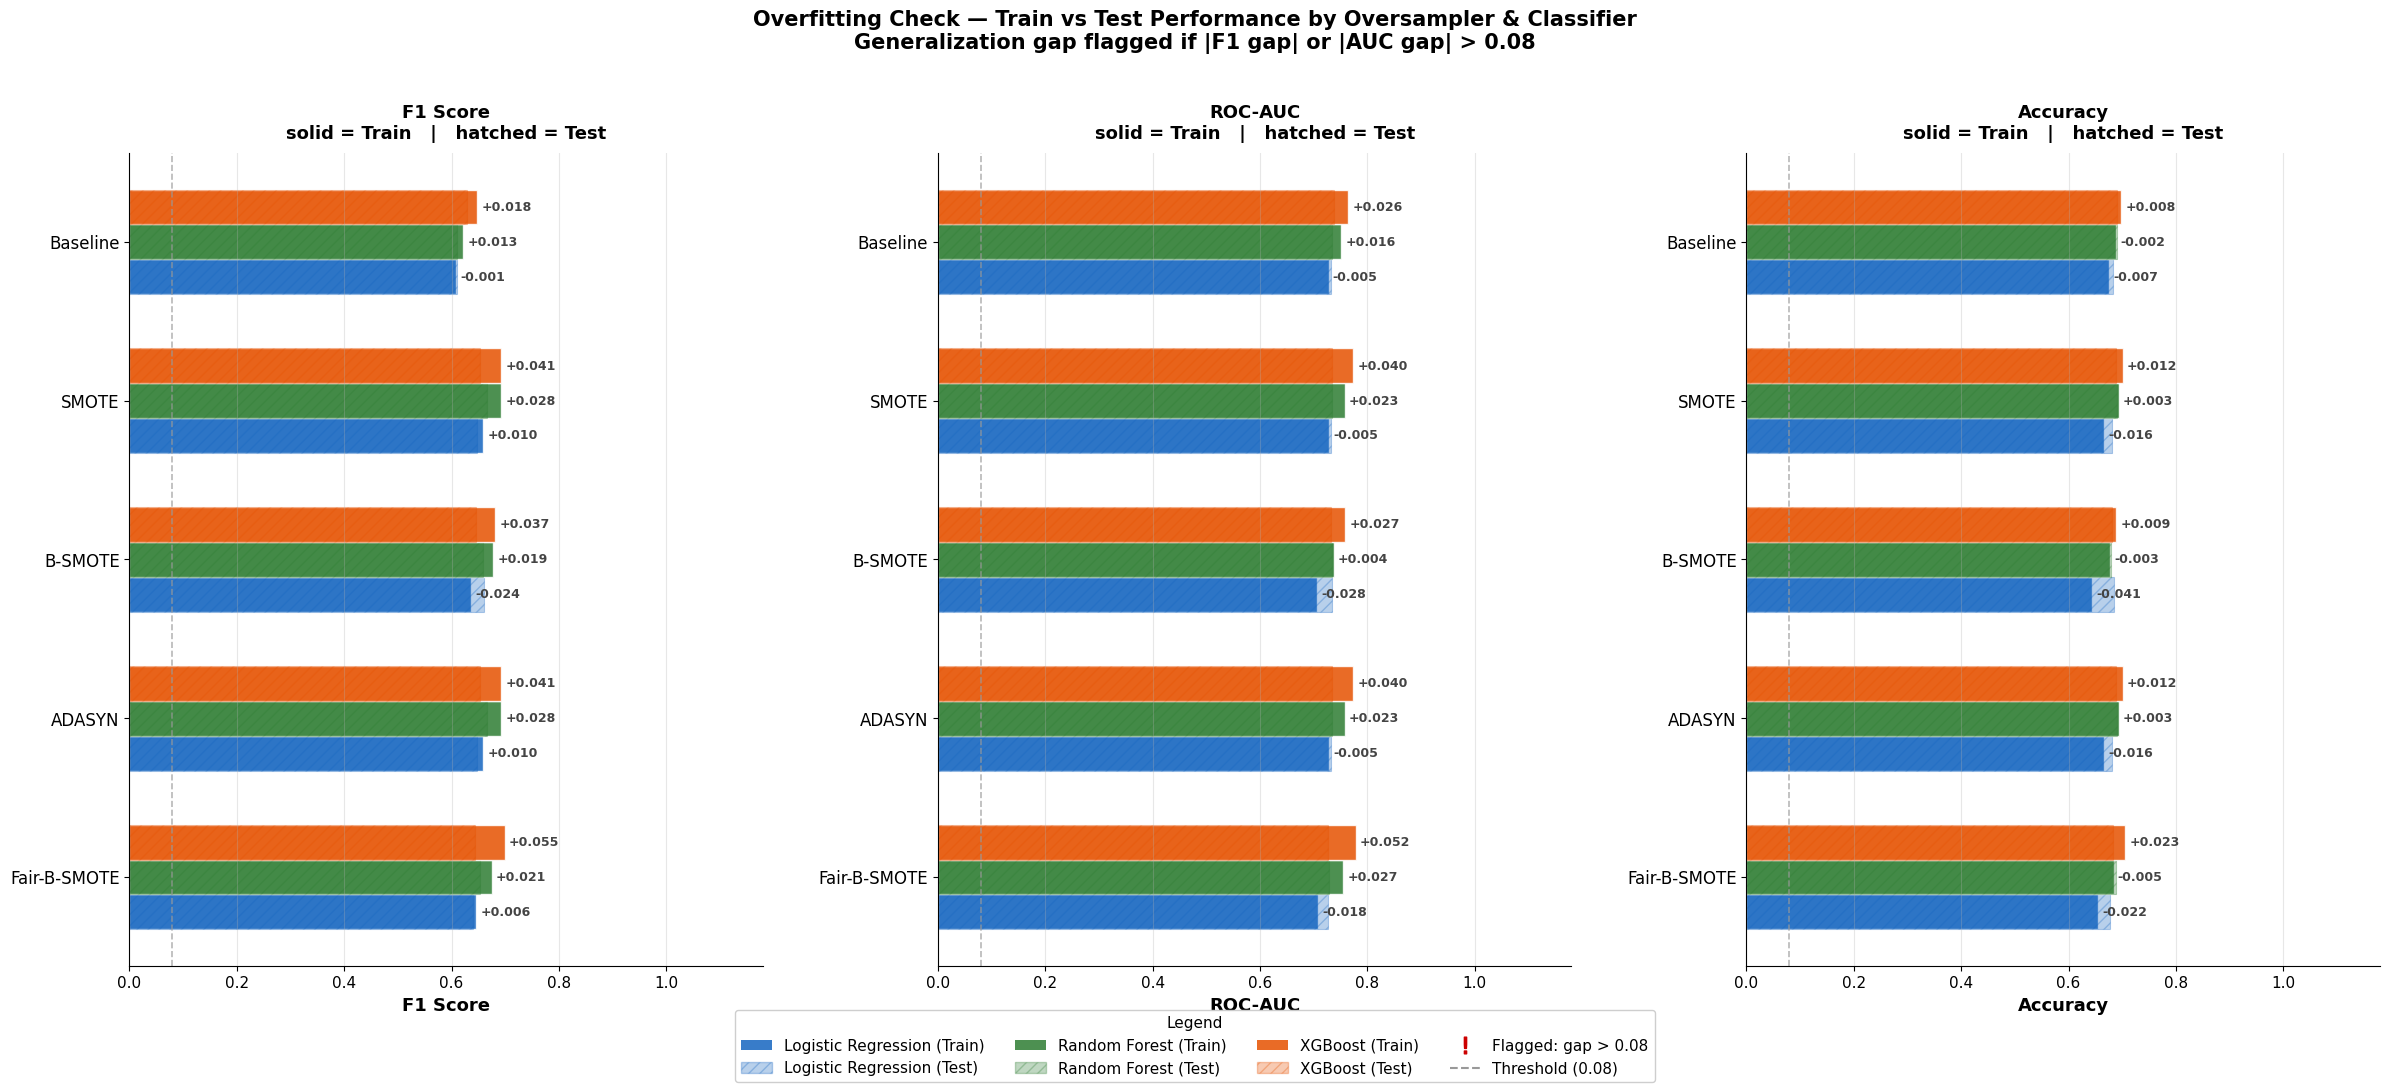

Saved plot_overfit_check.png


In [ ]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

CLF_COLORS = ['#1565C0', '#2E7D32', '#E65100']

short_labels = [
    o.replace('Fair-BorderlineSMOTE', 'Fair-B-SMOTE')
     .replace('BorderlineSMOTE', 'B-SMOTE')
    for o in OS_ORDER
]

fig, axes = plt.subplots(1, 3, figsize=(24, 10))
fig.suptitle(
    'Overfitting Check — Train vs Test Performance by Oversampler & Classifier\n'
    f'Generalization gap flagged if |F1 gap| or |AUC gap| > {OVERFIT_THRESH}',
    fontsize=15, fontweight='bold', y=1.02)

y = np.arange(len(OS_ORDER))
w = 0.22

metric_specs = [
    ('train_f1',  'test_f1',  'gap_f1',  'F1 Score'),
    ('train_auc', 'test_auc', 'gap_auc', 'ROC-AUC'),
    ('train_acc', 'test_accuracy', 'gap_acc', 'Accuracy'),
]

for ax, (tr_col, te_col, gap_col, title) in zip(axes, metric_specs):

    for i, (clf, clf_color) in enumerate(zip(CLF_ORDER, CLF_COLORS)):
        sub = (results_df[results_df['classifier'] == clf]
               .set_index('oversampler')
               .reindex(OS_ORDER))

        yi = y - i * w  # offset each classifier group upward

        # Train bars (solid)
        ax.barh(yi, sub[tr_col], height=w,
                color=clf_color, alpha=0.85,
                edgecolor='white', linewidth=1.0,
                label=f'{clf} — Train')

        # Test bars (hatched, lighter)
        ax.barh(yi, sub[te_col], height=w,
                color=clf_color, alpha=0.30,
                edgecolor=clf_color, hatch='///',
                linewidth=0.8,
                label=f'{clf} — Test')

        # Gap annotation to the right of the train bar
        for j in range(len(OS_ORDER)):
            xmax    = sub[tr_col].iloc[j]
            gap     = sub[gap_col].iloc[j]
            flagged = sub['flagged'].iloc[j]
            color   = '#cc0000' if flagged else '#444444'
            marker  = ' (!)' if flagged else ''
            ax.text(xmax + 0.008, yi[j],
                    f'{gap:+.3f}{marker}',
                    ha='left', va='center',
                    fontsize=9, fontweight='bold',
                    color=color)

    # Threshold reference line
    ax.axvline(x=OVERFIT_THRESH, color='#999999',
               linestyle='--', linewidth=1.2, alpha=0.7,
               label=f'Threshold ({OVERFIT_THRESH})')

    # Y-axis — oversampler labels centred across the 3 classifier offsets
    ax.set_yticks(y - w)
    ax.set_yticklabels(short_labels, fontsize=12)
    ax.invert_yaxis()   # top-to-bottom order matches OS_ORDER

    ax.set_xlabel(title, fontsize=13, fontweight='bold')
    ax.set_title(
        f'{title}\nsolid = Train   |   hatched = Test',
        fontsize=13, fontweight='bold', pad=10)
    ax.tick_params(axis='x', labelsize=11)
    ax.set_xlim(left=0, right=1.18)
    ax.grid(axis='x', alpha=0.3, linewidth=0.8)
    ax.spines[['top', 'right']].set_visible(False)


# ── Shared footer legend ──────────────────────────────────────────────────────
legend_handles = []
for clf, col in zip(CLF_ORDER, CLF_COLORS):
    legend_handles.append(
        Patch(facecolor=col, alpha=0.85,
              label=f'{clf} (Train)'))
    legend_handles.append(
        Patch(facecolor=col, alpha=0.30,
              hatch='///', edgecolor=col,
              label=f'{clf} (Test)'))
legend_handles.append(
    Line2D([0], [0], color='#cc0000', linewidth=0,
           marker='$!$', markersize=12,
           label=f'Flagged: gap > {OVERFIT_THRESH}'))
legend_handles.append(
    Line2D([0], [0], color='#999999', linewidth=1.5,
           linestyle='--',
           label=f'Threshold ({OVERFIT_THRESH})'))

fig.legend(handles=legend_handles,
           loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.06),
           fontsize=11, framealpha=0.95,
           title='Legend', title_fontsize=11)

plt.tight_layout(w_pad=4)
plt.savefig('plot_overfit_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot_overfit_check.png')

---
## 7. Results Tables


In [ ]:
# Performance metrics
print('COMPAS — Performance Metrics')
performance_metrics_df = results_df.set_index(['classifier','oversampler']) \
                                   [['test_f1','test_auc','test_accuracy','test_precision','test_recall']].round(4).rename(columns={
                                       'test_f1': 'F1', 'test_auc': 'AUC', 'test_accuracy': 'Accuracy',
                                       'test_precision': 'Precision', 'test_recall': 'Recall'
                                   })
display(performance_metrics_df)

# Fairness metrics
print('''
COMPAS — Gender Fairness Metrics''')
fairness_metrics_df = results_df.set_index(['classifier','oversampler']) \
                                [['dp_diff','tpr_diff','fpr_diff']].round(4)
display(fairness_metrics_df)

# Per-gender rates
print('''
COMPAS — Positive Prediction Rate & TPR by Gender''')
gender_rates_df = results_df.set_index(['classifier','oversampler']) \
                            [['rate_female','rate_male','tpr_female','tpr_male','fpr_female','fpr_male']].round(4)
display(gender_rates_df)

COMPAS — Performance Metrics


F1     AUC  Accuracy  Precision  \
classifier          oversampler                                                 
Logistic Regression Baseline              0.6094  0.7330    0.6834     0.6948   
                    SMOTE                 0.6482  0.7327    0.6818     0.6523   
                    BorderlineSMOTE       0.6597  0.7340    0.6842     0.6473   
                    ADASYN                0.6482  0.7327    0.6818     0.6523   
                    Fair-BorderlineSMOTE  0.6402  0.7267    0.6769     0.6490   
Random Forest       Baseline              0.6096  0.7345    0.6899     0.7136   
                    SMOTE                 0.6655  0.7343    0.6907     0.6552   
                    BorderlineSMOTE       0.6586  0.7339    0.6794     0.6388   
                    ADASYN                0.6655  0.7343    0.6907     0.6552   
                    Fair-BorderlineSMOTE  0.6534  0.7283    0.6891     0.6630   
XGBoost             Baseline              0.6292  0.7378    0.6899     0.6900   
                    SMOTE                 0.6522  0.7338    0.6883     0.6624   
                    BorderlineSMOTE       0.6451  0.7318    0.6802     0.6515   
                    ADASYN                0.6522  0.7338    0.6883     0.6624   
                    Fair-BorderlineSMOTE  0.6436  0.7263    0.6826     0.6580   

                                          Recall  
classifier          oversampler                   
Logistic Regression Baseline              0.5427  
                    SMOTE                 0.6441  
                    BorderlineSMOTE       0.6726  
                    ADASYN                0.6441  
                    Fair-BorderlineSMOTE  0.6317  
Random Forest       Baseline              0.5320  
                    SMOTE                 0.6762  
                    BorderlineSMOTE       0.6797  
                    ADASYN                0.6762  
                    Fair-BorderlineSMOTE  0.6441  
XGBoost             Baseline              0.5783  
                    SMOTE                 0.6423  
                    BorderlineSMOTE       0.6388  
                    ADASYN                0.6423  
                    Fair-BorderlineSMOTE  0.6299


COMPAS — Gender Fairness Metrics


dp_diff  tpr_diff  fpr_diff
classifier          oversampler                                      
Logistic Regression Baseline               0.2900    0.3206    0.2119
                    SMOTE                  0.3423    0.3154    0.2983
                    BorderlineSMOTE        0.3660    0.3489    0.3144
                    ADASYN                 0.3423    0.3154    0.2983
                    Fair-BorderlineSMOTE   0.0592    0.0789    0.0154
Random Forest       Baseline               0.2171    0.2110    0.1593
                    SMOTE                  0.2985    0.2422    0.2684
                    BorderlineSMOTE        0.2741    0.2325    0.2382
                    ADASYN                 0.2985    0.2422    0.2684
                    Fair-BorderlineSMOTE   0.1588    0.1213    0.1166
XGBoost             Baseline               0.2320    0.2101    0.1828
                    SMOTE                  0.2688    0.2578    0.2119
                    BorderlineSMOTE        0.2590    0.2398    0.2098
                    ADASYN                 0.2688    0.2578    0.2119
                    Fair-BorderlineSMOTE   0.1296    0.1461    0.0560


COMPAS — Positive Prediction Rate & TPR by Gender


rate_female  rate_male  tpr_female  \
classifier          oversampler                                                
Logistic Regression Baseline                   0.1202     0.4102      0.2706   
                    SMOTE                      0.1717     0.5140      0.3765   
                    BorderlineSMOTE            0.1760     0.5419      0.3765   
                    ADASYN                     0.1717     0.5140      0.3765   
                    Fair-BorderlineSMOTE       0.3948     0.4541      0.5647   
Random Forest       Baseline                   0.1631     0.3802      0.3529   
                    SMOTE                      0.2275     0.5259      0.4706   
                    BorderlineSMOTE            0.2618     0.5359      0.4824   
                    ADASYN                     0.2275     0.5259      0.4706   
                    Fair-BorderlineSMOTE       0.3133     0.4721      0.5412   
XGBoost             Baseline                   0.1931     0.4251      0.4000   
                    SMOTE                      0.2232     0.4920      0.4235   
                    BorderlineSMOTE            0.2361     0.4950      0.4353   
                    ADASYN                     0.2232     0.4920      0.4235   
                    Fair-BorderlineSMOTE       0.3305     0.4601      0.5059   

                                          tpr_male  fpr_female  fpr_male  
classifier          oversampler                                           
Logistic Regression Baseline                0.5912      0.0338    0.2457  
                    SMOTE                   0.6918      0.0541    0.3524  
                    BorderlineSMOTE         0.7254      0.0608    0.3752  
                    ADASYN                  0.6918      0.0541    0.3524  
                    Fair-BorderlineSMOTE    0.6436      0.2973    0.2819  
Random Forest       Baseline                0.5639      0.0541    0.2133  
                    SMOTE                   0.7128      0.0878    0.3562  
                    BorderlineSMOTE         0.7149      0.1351    0.3733  
                    ADASYN                  0.7128      0.0878    0.3562  
                    Fair-BorderlineSMOTE    0.6625      0.1824    0.2990  
XGBoost             Baseline                0.6101      0.0743    0.2571  
                    SMOTE                   0.6813      0.1081    0.3200  
                    BorderlineSMOTE         0.6751      0.1216    0.3314  
                    ADASYN                  0.6813      0.1081    0.3200  
                    Fair-BorderlineSMOTE    0.6520      0.2297    0.2857

In [ ]:
# Summary averaged across classifiers
print('Summary — averaged across all three classifiers:')
summary = (results_df
           .groupby('oversampler', observed=True)
           [['test_f1','test_auc','test_accuracy','test_precision','test_recall',
             'dp_diff','tpr_diff','fpr_diff',
             'rate_female','rate_male','tpr_female','tpr_male']]
           .mean().round(4))
display(summary)


Summary — averaged across all three classifiers:


,test_f1,test_auc,test_accuracy,test_precision,test_recall,dp_diff,tpr_diff,fpr_diff,rate_female,rate_male,tpr_female,tpr_male
oversampler,,,,,,,,,,,,
Baseline,0.6161,0.7351,0.6877,0.6995,0.5510,0.2464,0.2472,0.1847,0.1588,0.4052,0.3412,0.5884
SMOTE,0.6553,0.7336,0.6869,0.6566,0.6542,0.3032,0.2718,0.2595,0.2074,0.5106,0.4235,0.6953
BorderlineSMOTE,0.6545,0.7332,0.6813,0.6459,0.6637,0.2997,0.2737,0.2541,0.2246,0.5243,0.4314,0.7051
ADASYN,0.6553,0.7336,0.6869,0.6566,0.6542,0.3032,0.2718,0.2595,0.2074,0.5106,0.4235,0.6953
Fair-BorderlineSMOTE,0.6457,0.7271,0.6829,0.6567,0.6352,0.1159,0.1154,0.0627,0.3462,0.4621,0.5373,0.6527


###Heatmap: Summary averaged across classifiers

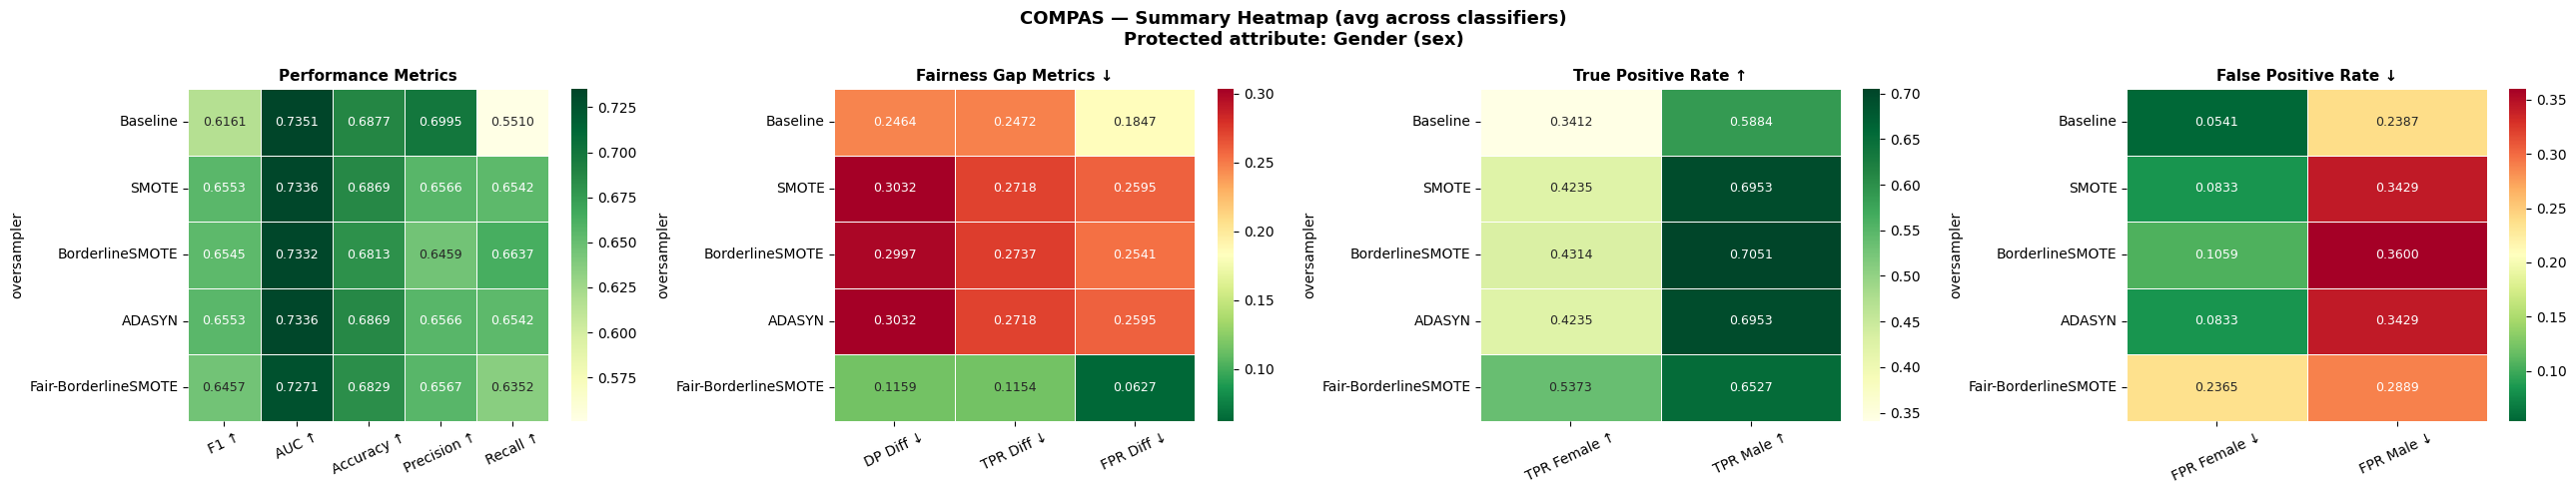

Saved plot_summary_heatmap.png


In [ ]:
# Summary heatmap averaged across classifiers
summary = (results_df
           .groupby('oversampler', observed=True)
           [['test_f1', 'test_auc', 'test_accuracy', 'test_precision', 'test_recall',
             'dp_diff', 'tpr_diff', 'fpr_diff',
             'tpr_female', 'tpr_male', 'fpr_female', 'fpr_male']]
           .mean().round(4)
           .reindex(OS_ORDER))

# Rename columns for display
summary.columns = [
    'F1 ↑', 'AUC ↑', 'Accuracy ↑', 'Precision ↑', 'Recall ↑',
    'DP Diff ↓', 'TPR Diff ↓', 'FPR Diff ↓',
    'TPR Female ↑', 'TPR Male ↑', 'FPR Female ↓', 'FPR Male ↓',
]

# Split into two groups for separate colormaps
perf_cols      = ['F1 ↑', 'AUC ↑', 'Accuracy ↑', 'Precision ↑', 'Recall ↑']
fairness_cols  = ['DP Diff ↓', 'TPR Diff ↓', 'FPR Diff ↓']
tpr_cols       = ['TPR Female ↑', 'TPR Male ↑']
fpr_cols       = ['FPR Female ↓', 'FPR Male ↓']

fig, axes = plt.subplots(1, 4, figsize=(26, 5))
fig.suptitle(
    'COMPAS — Summary Heatmap (avg across classifiers)\n'
    'Protected attribute: Gender (sex)',
    fontsize=13, fontweight='bold')

heatmap_specs = [
    (perf_cols,     'Performance Metrics',        'YlGn',    '.4f'),
    (fairness_cols, 'Fairness Gap Metrics ↓',     'RdYlGn_r','.4f'),
    (tpr_cols,      'True Positive Rate ↑',        'YlGn',    '.4f'),
    (fpr_cols,      'False Positive Rate ↓',       'RdYlGn_r','.4f'),
]

for ax, (cols, title, cmap, fmt) in zip(axes, heatmap_specs):
    sns.heatmap(
        summary[cols],
        ax=ax,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        linewidths=0.5,
        annot_kws={'size': 9},
        cbar=True,
    )
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('plot_summary_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot_summary_heatmap.png')


---
## 8. Visualisations


In [ ]:
COLORS = {
    'Baseline':             '#757575',
    'SMOTE':                '#43A047',
    'BorderlineSMOTE':      '#1E88E5',
    'ADASYN':               '#FB8C00',
    'Fair-BorderlineSMOTE': '#E53935',
}
CLF_COLORS = ['#1565C0', '#2E7D32', '#E65100']
print('Palette ready.')


Palette ready.


###Plot 1: F1, Dem. Parity, EO TPR, EO FPR across classifiers

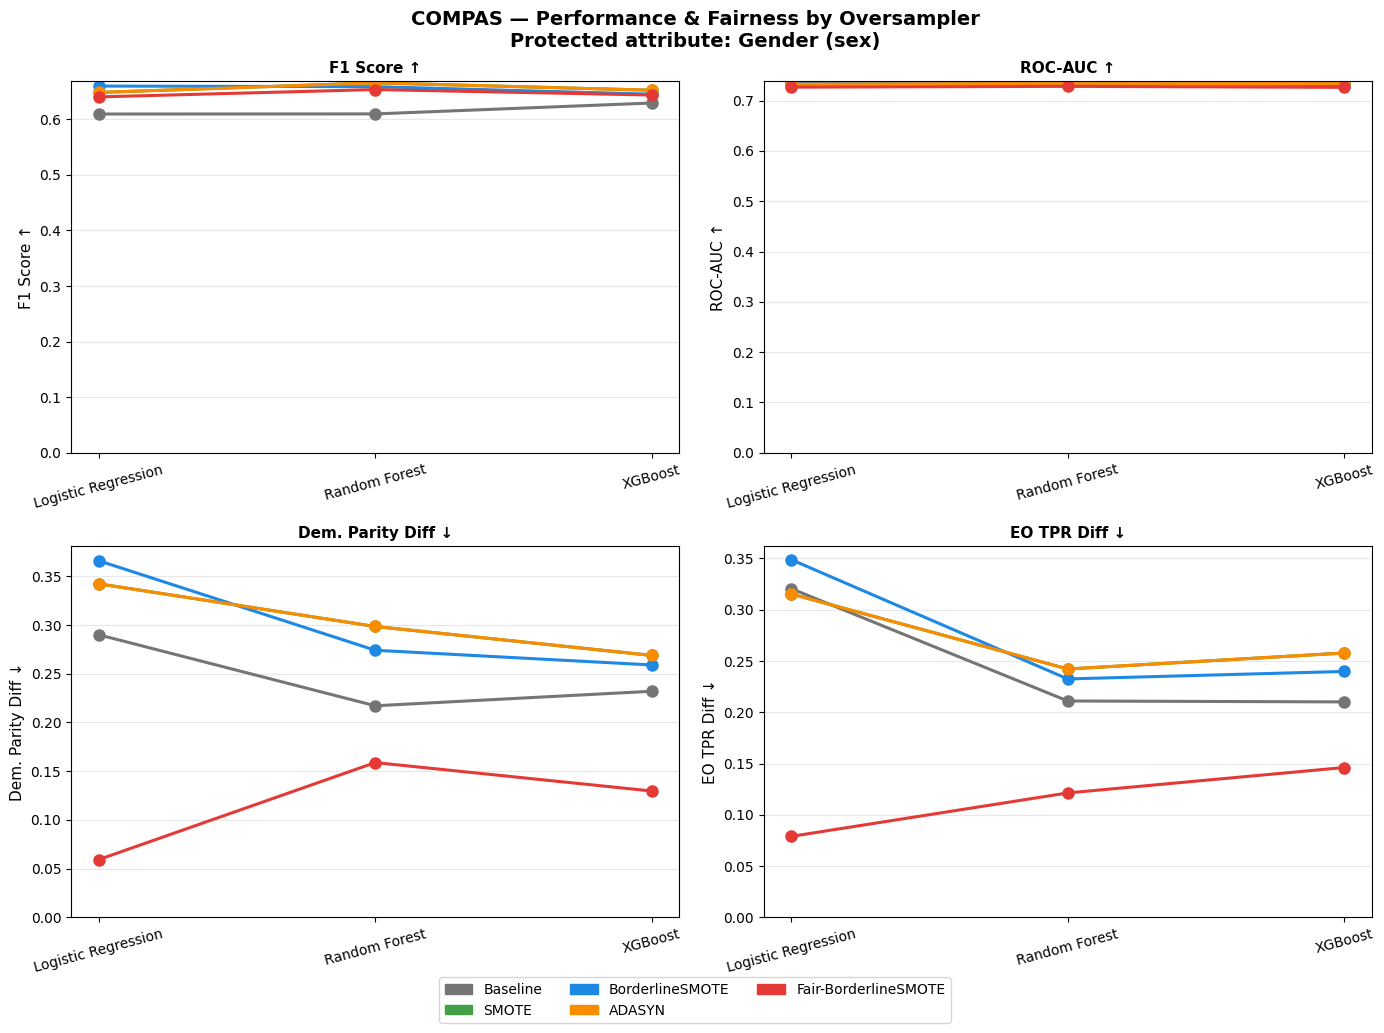

Saved plot_lines.png


In [ ]:
# Plot 1: F1, Dem. Parity, EO TPR, EO FPR across classifiers
metrics_plot = [
    ('test_f1',       'F1 Score ↑'),
    ('test_auc',      'ROC-AUC ↑'),
    ('dp_diff',  'Dem. Parity Diff ↓'),
    ('tpr_diff', 'EO TPR Diff ↓'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'COMPAS — Performance & Fairness by Oversampler\n'
    'Protected attribute: Gender (sex)',
    fontsize=14, fontweight='bold')

for ax, (metric, ylabel) in zip(axes.flat, metrics_plot):
    for os_n in OS_ORDER:
        vals = [
            results_df[
                (results_df['oversampler'] == os_n) &
                (results_df['classifier']  == c)
            ][metric].values
            for c in CLF_ORDER
        ]
        means = [v[0] if len(v) else np.nan for v in vals]
        ax.plot(CLF_ORDER, means, marker='o',
                color=COLORS[os_n], label=os_n,
                linewidth=2.2, markersize=8)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(bottom=0)
    ax.grid(axis='y', alpha=0.3)

handles = [mpatches.Patch(color=COLORS[o], label=o) for o in OS_ORDER]
fig.legend(handles=handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.04), fontsize=10)
plt.tight_layout()
plt.savefig('plot_lines.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot_lines.png')


### Plot 2: Heatmap — oversampler x metric (avg across classifiers)

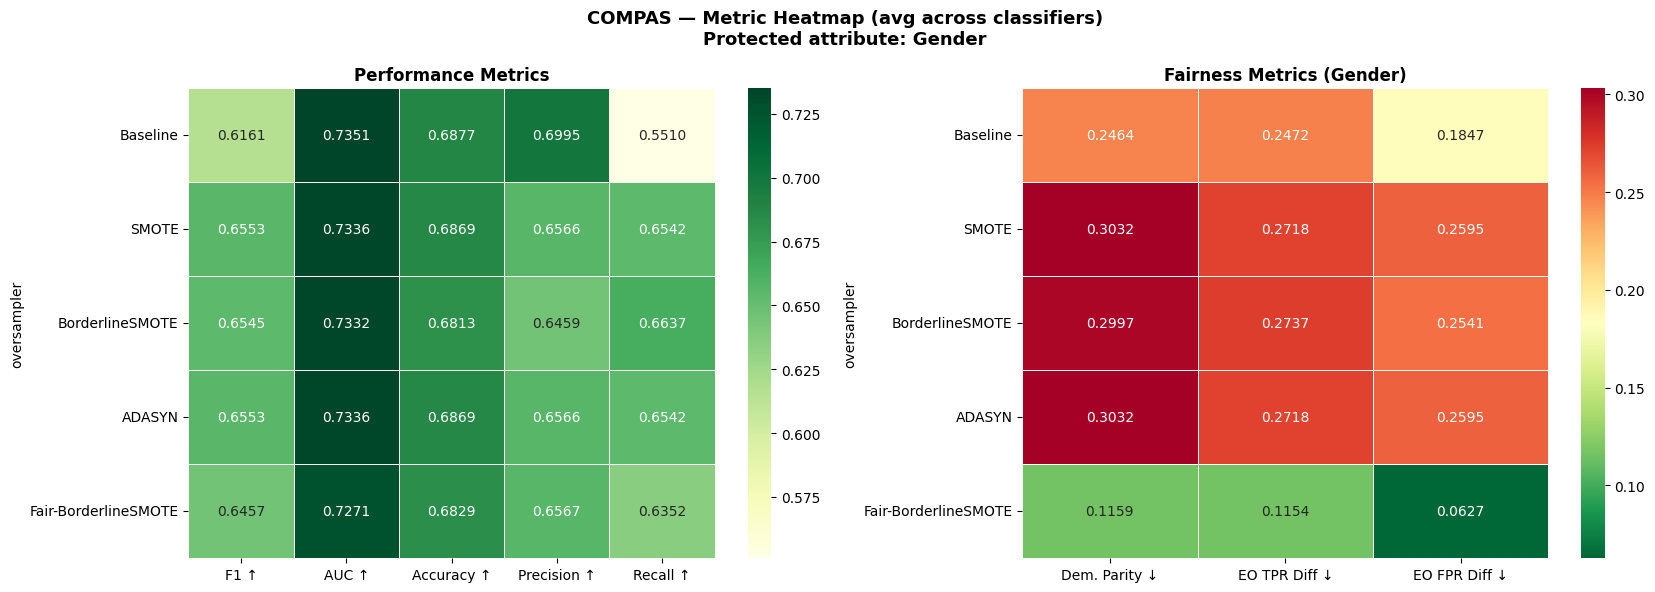

Saved plot_heatmap.png


In [ ]:
# Plot 2: Heatmap — oversampler x metric (avg across classifiers)
heat_metrics = ['test_f1', 'test_auc', 'test_accuracy', 'test_precision', 'test_recall',
                'dp_diff', 'tpr_diff', 'fpr_diff']
heat_labels  = ['F1 ↑', 'AUC ↑', 'Accuracy ↑', 'Precision ↑', 'Recall ↑',
                'Dem. Parity ↓', 'EO TPR Diff ↓', 'EO FPR Diff ↓']

heat_data = (results_df
             .groupby('oversampler', observed=True)[heat_metrics]
             .mean().reindex(OS_ORDER).round(4))
heat_data.columns = heat_labels

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle(
    'COMPAS — Metric Heatmap (avg across classifiers)\n'
    'Protected attribute: Gender',
    fontsize=13, fontweight='bold')

# Left: performance (5 metrics)
sns.heatmap(heat_data[heat_labels[:5]], ax=axes[0],
            annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, annot_kws={'size': 10})
axes[0].set_title('Performance Metrics', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='y', rotation=0)

# Right: fairness (3 metrics)
sns.heatmap(heat_data[heat_labels[5:]], ax=axes[1],
            annot=True, fmt='.4f', cmap='RdYlGn_r',
            linewidths=0.5, annot_kws={'size': 10})
axes[1].set_title('Fairness Metrics (Gender)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('plot_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot_heatmap.png')

###Plot 3: Grouped bar — F1, AUC, Accuracy, Precision, Recall, Dem. Parity, EO TPR Diff, EO FPR Diff

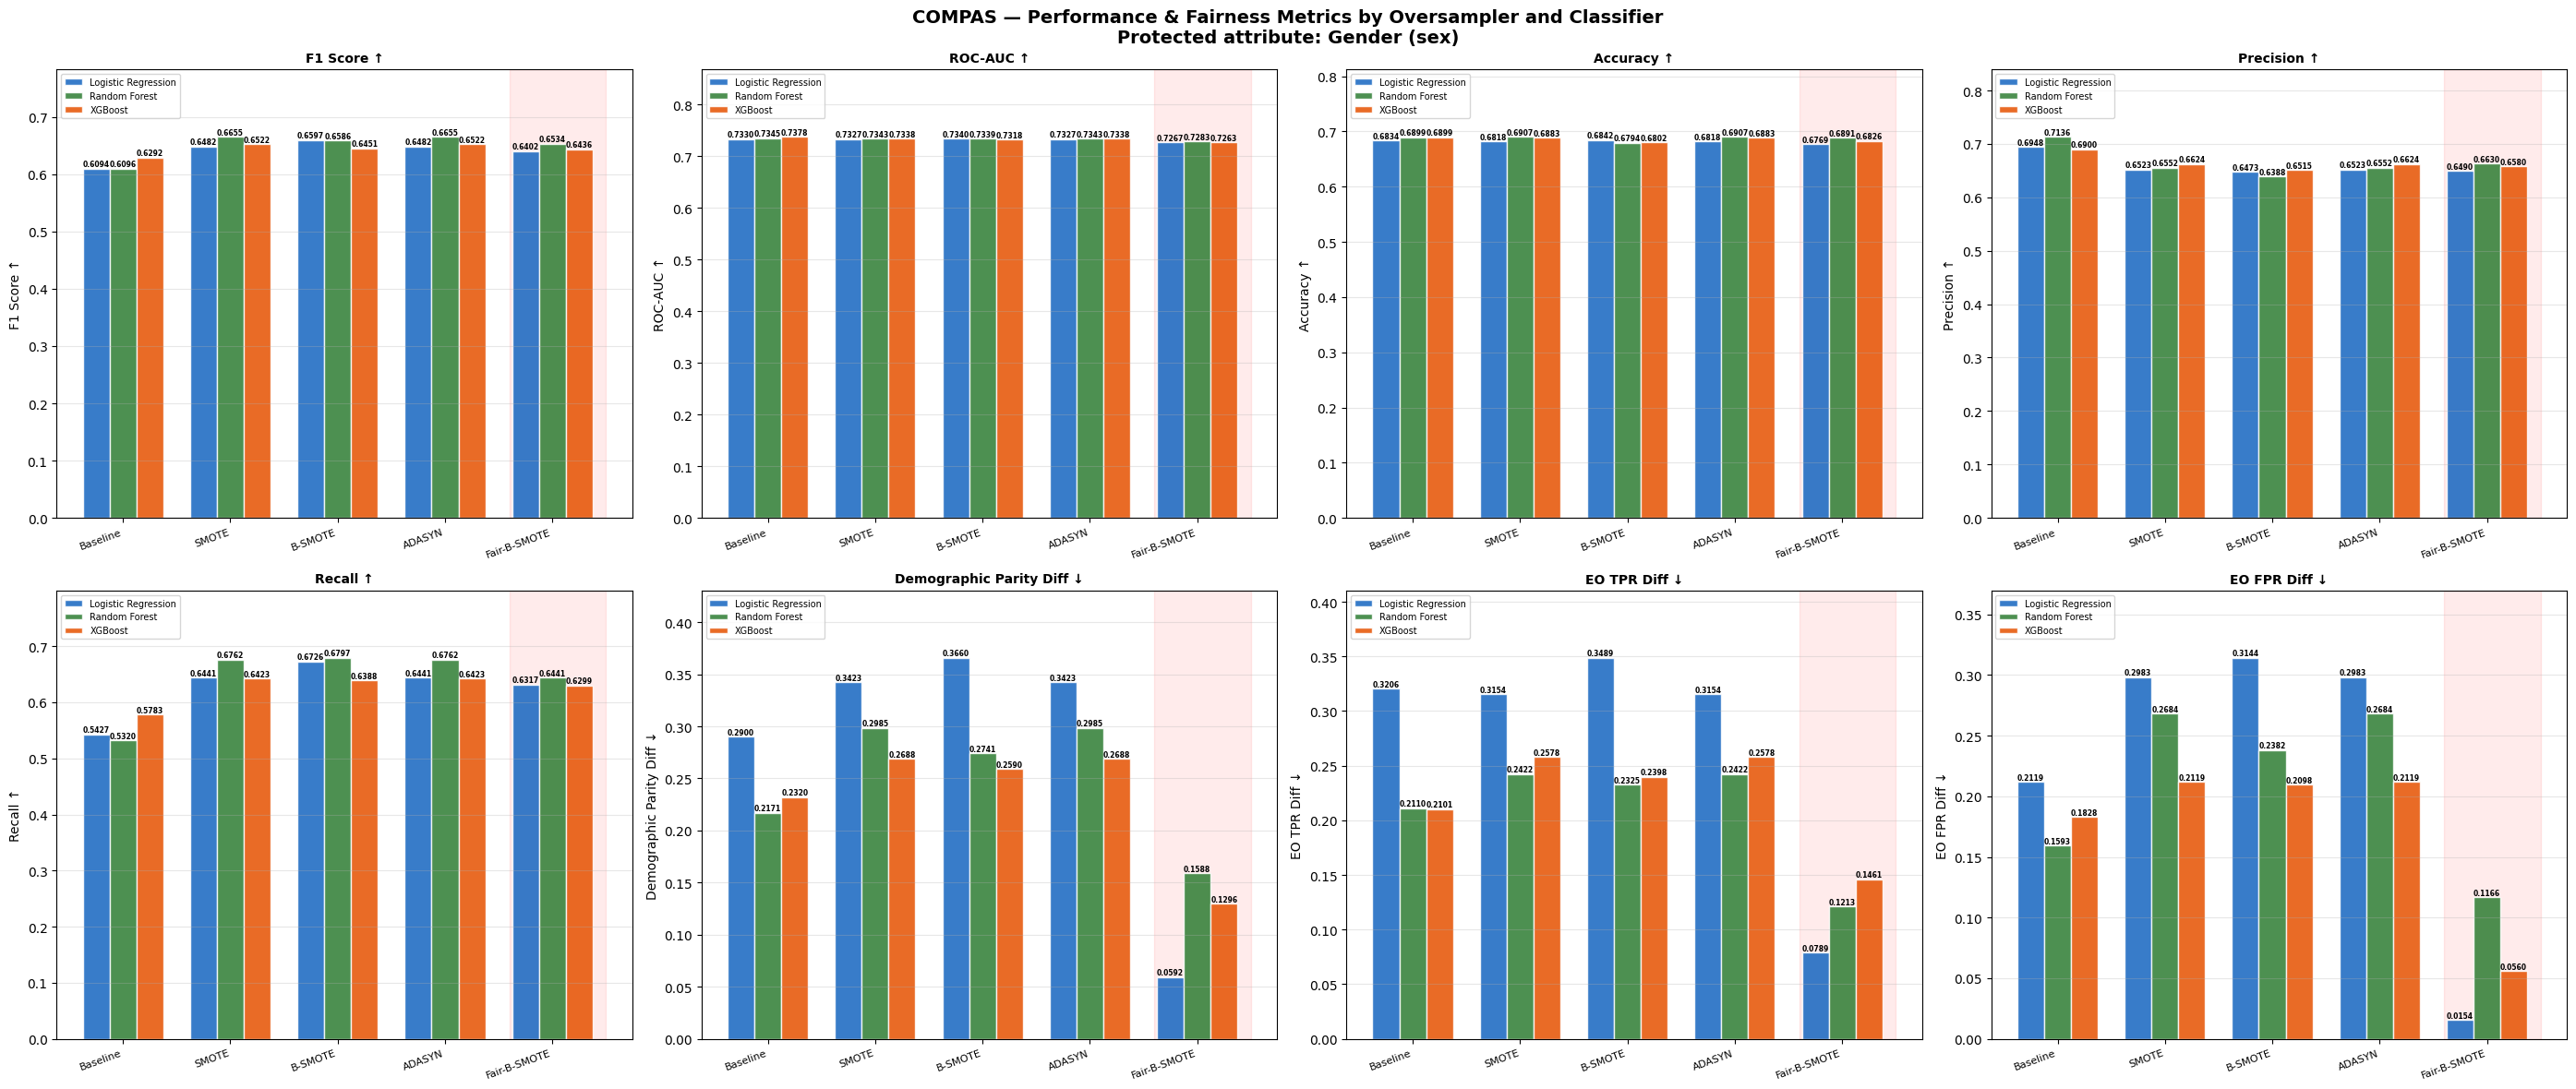

Saved plot_bars.png


In [ ]:
# Plot 3: Grouped bar — F1, AUC, Accuracy, Precision, Recall, Dem. Parity, EO TPR Diff, EO FPR Diff
short_labels = [
    o.replace('Fair-BorderlineSMOTE', 'Fair-B-SMOTE')
     .replace('BorderlineSMOTE', 'B-SMOTE')
    for o in OS_ORDER
]

metric_specs = [
    ('test_f1',        'F1 Score ↑'),
    ('test_auc',       'ROC-AUC ↑'),
    ('test_accuracy',  'Accuracy ↑'),
    ('test_precision', 'Precision ↑'),
    ('test_recall',    'Recall ↑'),
    ('dp_diff',   'Demographic Parity Diff ↓'),
    ('tpr_diff',  'EO TPR Diff ↓'),
    ('fpr_diff',  'EO FPR Diff ↓'),
]

fig, axes = plt.subplots(2, 4, figsize=(28, 12))
fig.suptitle(
    'COMPAS — Performance & Fairness Metrics by Oversampler and Classifier\n'
    'Protected attribute: Gender (sex)',
    fontsize=14, fontweight='bold')

x = np.arange(len(OS_ORDER))
w = 0.25

for ax, (metric, ylabel) in zip(axes.flat, metric_specs):

    bar_data = (results_df
                .groupby(['oversampler', 'classifier'], observed=True)[metric]
                .mean()
                .unstack('classifier')
                .reindex(OS_ORDER)[CLF_ORDER])

    for i, (clf, col) in enumerate(zip(CLF_ORDER, CLF_COLORS)):
        bars = ax.bar(
            x + i * w,
            bar_data[clf],
            width=w,
            label=clf,
            color=col,
            alpha=0.85,
            edgecolor='white'
        )
        # Numeric labels on top of each bar
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + ax.get_ylim()[1] * 0.001,
                f'{height:.4f}',
                ha='center', va='bottom',
                fontsize=5.5, fontweight='bold'
            )

    # Highlight Fair-BorderlineSMOTE column (index 4)
    ax.axvspan(3.85, 4.75, alpha=0.08, color='red', zorder=0)

    ax.set_xticks(x + w)
    ax.set_xticklabels(short_labels, fontsize=8, rotation=20, ha='right')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(ylabel, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(bottom=0)
    # Pad y-axis top so labels don't clip
    ax.set_ylim(top=ax.get_ylim()[1] * 1.12)

plt.tight_layout()
plt.savefig('plot_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot_bars.png')

###Plot 4: Per-gender positive prediction rate and TPR and FPR side by side

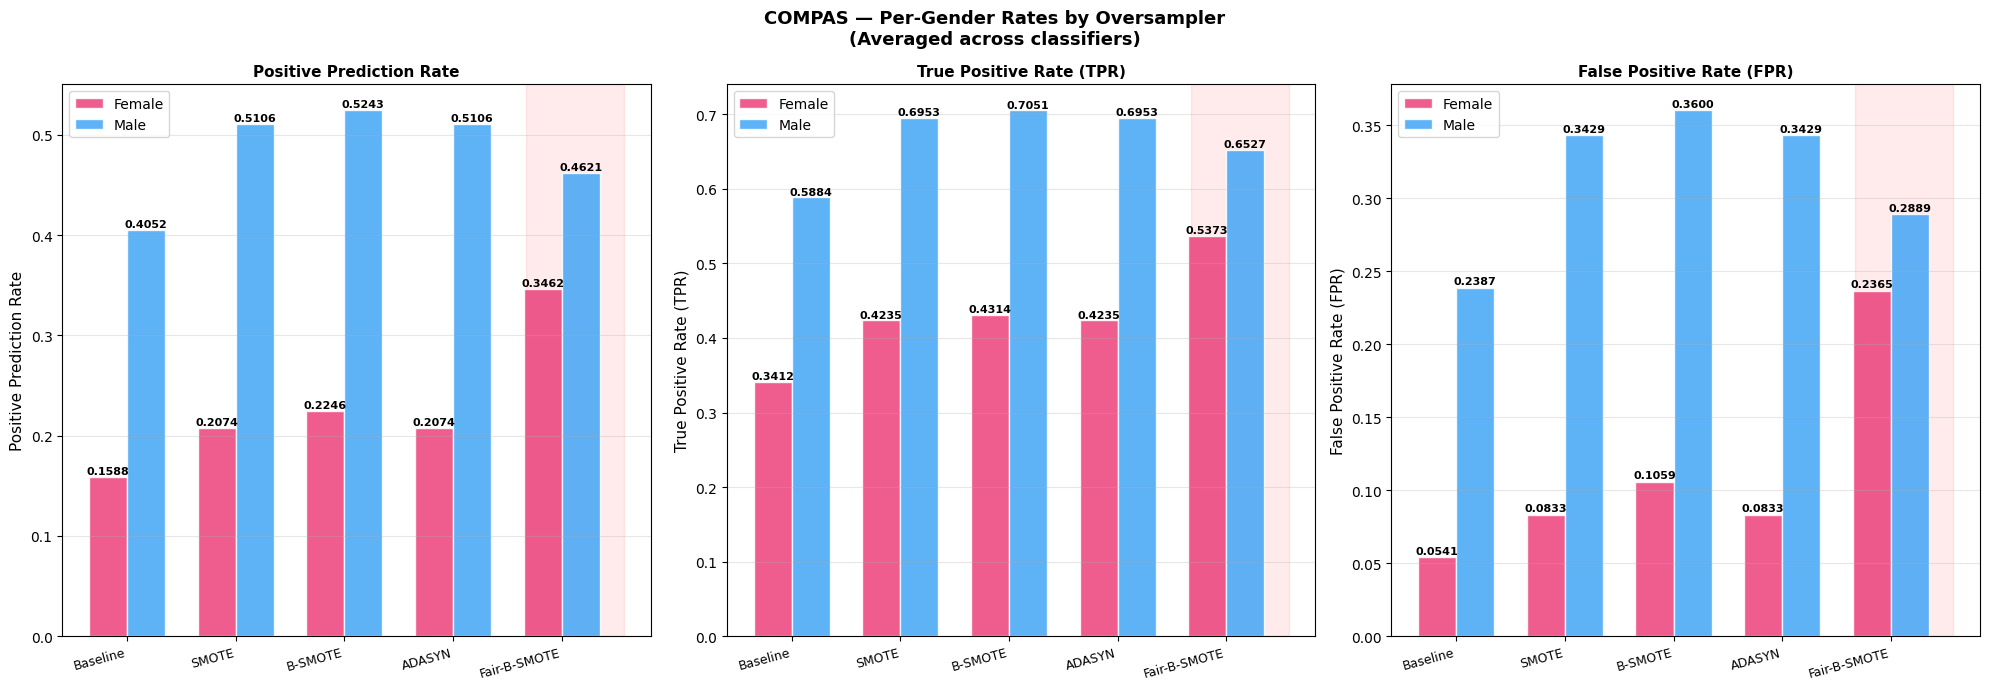

Saved plot_gender_rates.png


In [ ]:
# Plot 4: Per-gender positive prediction rate and TPR and FPR side by side
gender_metrics = [
    (['rate_female','rate_male'], 'Positive Prediction Rate'),
    (['tpr_female', 'tpr_male'],  'True Positive Rate (TPR)'),
    (['fpr_female', 'fpr_male'],  'False Positive Rate (FPR)'),
]

gender_colors = ['#EC407A', '#42A5F5']   # pink=Female, blue=Male
gender_labels = ['Female', 'Male']

x = np.arange(len(OS_ORDER))
w = 0.35

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

fig.suptitle(
    'COMPAS — Per-Gender Rates by Oversampler\n'
    '(Averaged across classifiers)',
    fontsize=13,
    fontweight='bold'
)

for ax, (cols, ylabel) in zip(axes, gender_metrics):
    grp = (results_df
           .groupby('oversampler', observed=True)[cols]
           .mean()
           .reindex(OS_ORDER))

    for i, (col, gc, gl) in enumerate(zip(cols, gender_colors, gender_labels)):
        bars = ax.bar(
            x + i*w,
            grp[col],
            width=w,
            label=gl,
            color=gc,
            alpha=0.85,
            edgecolor='white'
        )

        # Add numeric labels on top of bars
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.001,
                f'{height:.4f}',
                ha='center',
                va='bottom',
                fontsize=8,
                rotation=0,
                fontweight='bold'   # <-- makes numbers bold
            )

    ax.axvspan(3.85, 4.75, alpha=0.08, color='red', zorder=0)

    ax.set_xticks(x + w/2)
    ax.set_xticklabels(short_labels, fontsize=9, rotation=15, ha='right')

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=11, fontweight='bold')

    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('plot_gender_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved plot_gender_rates.png')

###Plot 5: Per-gender TPR and FPR side by side

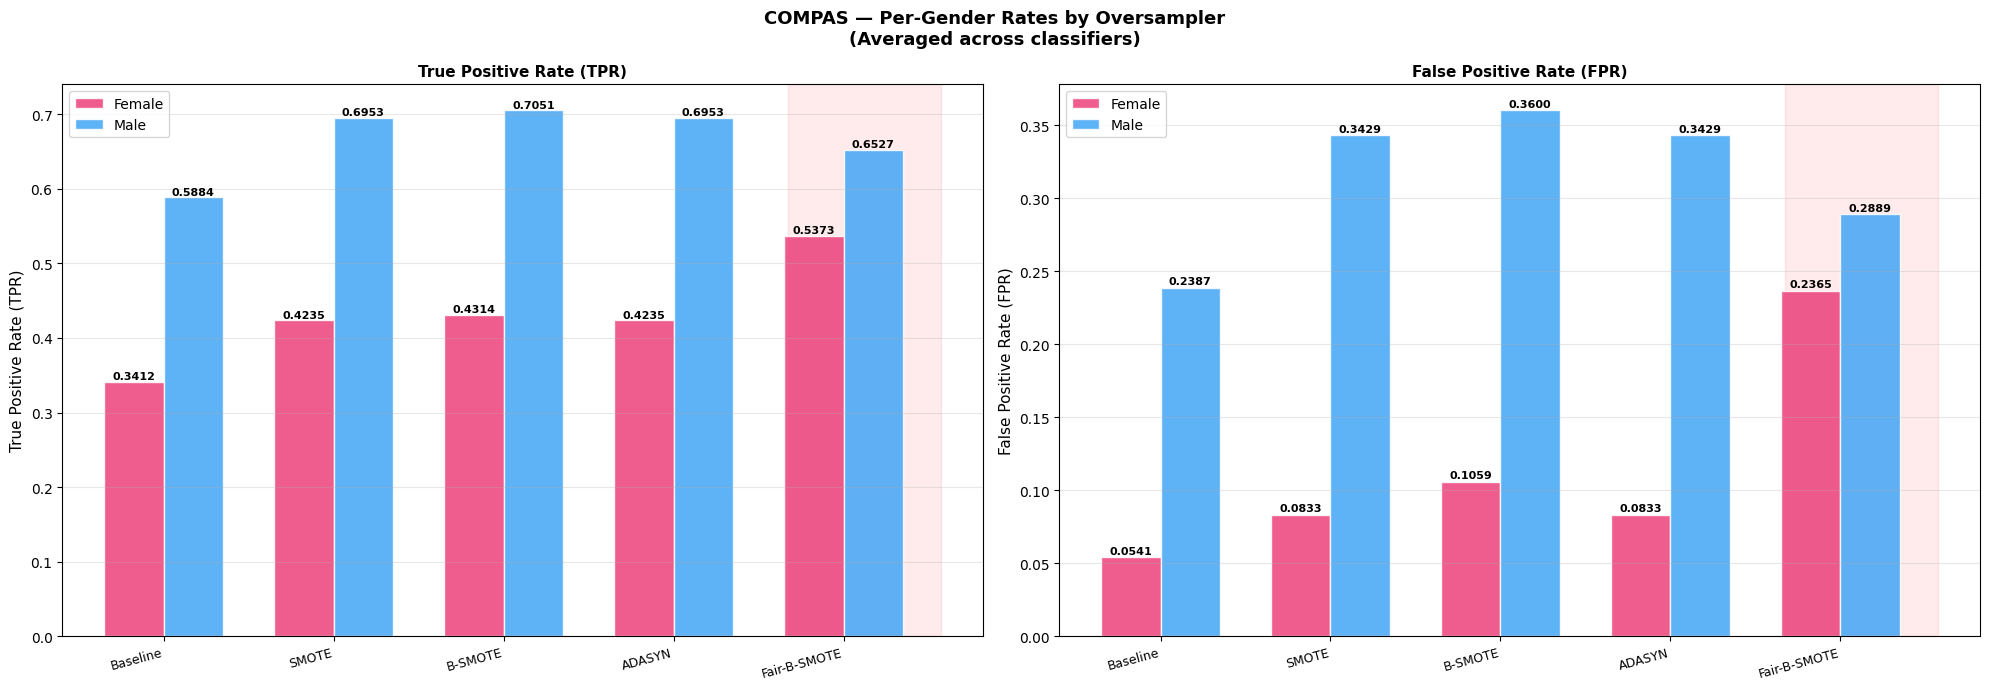

Saved plot_gender_rates.png


In [ ]:
# Plot 5: Per-gender TPR and FPR side by side
gender_metrics = [
    (['tpr_female', 'tpr_male'],  'True Positive Rate (TPR)'),
    (['fpr_female', 'fpr_male'],  'False Positive Rate (FPR)'),
]

gender_colors = ['#EC407A', '#42A5F5']   # pink=Female, blue=Male
gender_labels = ['Female', 'Male']

x = np.arange(len(OS_ORDER))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

fig.suptitle(
    'COMPAS — Per-Gender Rates by Oversampler\n'
    '(Averaged across classifiers)',
    fontsize=13,
    fontweight='bold'
)

for ax, (cols, ylabel) in zip(axes, gender_metrics):
    grp = (results_df
           .groupby('oversampler', observed=True)[cols]
           .mean()
           .reindex(OS_ORDER))

    for i, (col, gc, gl) in enumerate(zip(cols, gender_colors, gender_labels)):
        bars = ax.bar(
            x + i*w,
            grp[col],
            width=w,
            label=gl,
            color=gc,
            alpha=0.85,
            edgecolor='white'
        )

        # Add numeric labels on top of bars
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.001,
                f'{height:.4f}',
                ha='center',
                va='bottom',
                fontsize=8,
                rotation=0,
                fontweight='bold'   # <-- makes numbers bold
            )

    ax.axvspan(3.85, 4.75, alpha=0.08, color='red', zorder=0)

    ax.set_xticks(x + w/2)
    ax.set_xticklabels(short_labels, fontsize=9, rotation=15, ha='right')

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=11, fontweight='bold')

    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('plot_gender_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved plot_gender_rates.png')

###Plot 6: Fair-BorderlineSMOTE synthesis log — borderline vs generated per subgroup

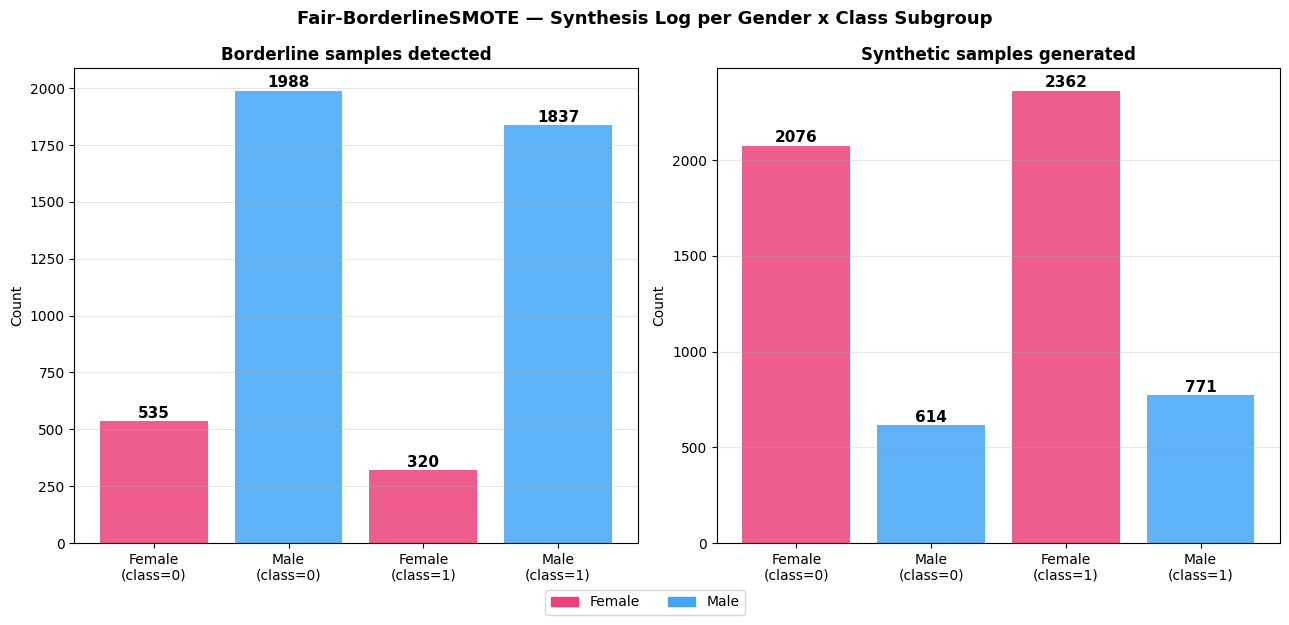

Saved plot_synthesis_log.png


In [ ]:
# Plot 6: Fair-BorderlineSMOTE synthesis log — borderline vs generated per subgroup
_, _, _, synth_log = fair_borderline_smote(X_tr_sc, y_tr, sex_tr, k=5, m=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(
    'Fair-BorderlineSMOTE — Synthesis Log per Gender x Class Subgroup',
    fontsize=13, fontweight='bold')

synth_log['label'] = (synth_log['gender'] + '\n(class=' +
                      synth_log['class'].astype(str) + ')')

bar_colors = ['#EC407A', '#42A5F5', '#EC407A', '#42A5F5']

# Left: borderline samples detected
bars0 = axes[0].bar(synth_log['label'], synth_log['borderline'],
                    color=bar_colors, alpha=0.85)
axes[0].set_title('Borderline samples detected', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars0, synth_log['borderline']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + axes[0].get_ylim()[1] * 0.001,
        str(int(val)),
        ha='center', va='bottom', fontsize=11, fontweight='bold')

# Right: synthetic samples generated
bars1 = axes[1].bar(synth_log['label'], synth_log['generated'],
                    color=bar_colors, alpha=0.85)
axes[1].set_title('Synthetic samples generated', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, synth_log['generated']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + axes[1].get_ylim()[1] * 0.001,
        str(int(val)),
        ha='center', va='bottom', fontsize=11, fontweight='bold')

female_patch = mpatches.Patch(color='#EC407A', label='Female')
male_patch   = mpatches.Patch(color='#42A5F5', label='Male')
fig.legend(handles=[female_patch, male_patch], loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.savefig('plot_synthesis_log.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot_synthesis_log.png')

---
## 9. Export Results


In [ ]:
results_df.to_csv('compas_fair_bls_results.csv', index=False)
print(f'Results saved — {len(results_df)} rows  '
      f'({len(OVERSAMPLERS)} methods x {len(CLF_ORDER)} classifiers)')

print('\nSummary (avg across classifiers):')
display(results_df
        .groupby('oversampler', observed=True)
        [['test_f1', 'test_auc', 'test_accuracy','test_precision', 'test_recall',
          'dp_diff', 'tpr_diff', 'fpr_diff',
          'rate_female', 'rate_male']]
        .mean().round(4))

from google.colab import files
for fname in [
    'compas_fair_bls_results.csv',
    'plot_lines.png', 'plot_heatmap.png',
    'plot_bars.png',  'plot_gender_rates.png',
    'plot_synthesis_log.png',
]:
    try:
        files.download(fname)
    except Exception:
        print(f'  Could not auto-download {fname}')

Results saved — 15 rows  (5 methods x 3 classifiers)

Summary (avg across classifiers):


,test_f1,test_auc,test_accuracy,test_precision,test_recall,dp_diff,tpr_diff,fpr_diff,rate_female,rate_male
oversampler,,,,,,,,,,
Baseline,0.6161,0.7351,0.6877,0.6995,0.5510,0.2464,0.2472,0.1847,0.1588,0.4052
SMOTE,0.6553,0.7336,0.6869,0.6566,0.6542,0.3032,0.2718,0.2595,0.2074,0.5106
BorderlineSMOTE,0.6545,0.7332,0.6813,0.6459,0.6637,0.2997,0.2737,0.2541,0.2246,0.5243
ADASYN,0.6553,0.7336,0.6869,0.6566,0.6542,0.3032,0.2718,0.2595,0.2074,0.5106
Fair-BorderlineSMOTE,0.6457,0.7271,0.6829,0.6567,0.6352,0.1159,0.1154,0.0627,0.3462,0.4621


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 10. Metric Reference

### Performance

| Metric | Direction | Description |
|---|---|---|
| F1 Score | ↑ | Harmonic mean of precision and recall |
| ROC-AUC | ↑ | Discriminative ability, threshold-independent |
| Accuracy | ↑ | Overall fraction of correct predictions |
| Precision | ↑ | Fraction of predicted positives that are correct |
| Recall | ↑ | Fraction of actual positives correctly identified |

### Fairness (Gender)

| Metric | Direction | Description |
|---|---|---|
| Dem. Parity Diff | ↓ | Gap in positive prediction rates between male and female|P(ŷ=1|Male) − P(ŷ=1|Female)||
| EO TPR Diff | ↓ | True Positive Rate gap between Male and Female (equal opportunity) |
| EO FPR Diff | ↓ | False Positive Rate gap between Male and Female |

### Method comparison

| Method | Gender-aware | Mechanism |
|---|---|---|
| Baseline | ✗ | No resampling |
| SMOTE | ✗ | Interpolates between random minority-class neighbours |
| BorderlineSMOTE | ✗ | Focuses SMOTE synthesis on borderline minority samples |
| ADASYN | ✗ | Adaptive synthesis — more samples near harder instances |
| **Fair-BorderlineSMOTE** | **✓** | BorderlineSMOTE stratified by gender × class; within-group kNN guarantees no cross-gender interpolation |

### Fair-BorderlineSMOTE parameters

| Parameter | Value | Role |
|---|---|---|
| `k` | 5 | Within-group kNN neighbors used during synthesis |
| `m` | 10 | Full-dataset kNN neighbors used for borderline detection |
| `cr` | 0.8 | Crossover rate — probability of using interpolated value per feature |
| `f` | 0.8 | Scaling factor controlling interpolation step size |
